<a href="https://colab.research.google.com/github/GarimaGoyal05/2210990188-2210990314-2210990362-2210990464/blob/main/stockpredictionfinalgit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Install and Import Libraries**
This section ensures all necessary Python libraries for data acquisition, manipulation, analysis, and machine learning are installed and imported. It covers financial data (yfinance), numerical operations (numpy), data handling (pandas), plotting (matplotlib, seaborn, plotly), and machine learning (scikit-learn, ta, tensorflow, xgboost, prophet).


In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn ta  plotly

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=2281fe792cc282fcd12b5c11f3a452e3d26f186aaaf164b9f821bfbe059ce0e6
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


#### **Importing Libraries**
This cell imports specific modules from the installed libraries, making them available for use throughout the notebook. Common aliases like `pd` for pandas and `np` for numpy are used for brevity and convention.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

Creating List of NIFTY 50 Stocks

Purpose

In this stage ,we compile a list of the NIFTY50 companies ticker symbols.Later on ,historical stock price data will be downlaoded using these symbol

Description

50 significant firms listed on the Indian National Stock Exchange (NSE) are represented by the NIFTY 50 index.Each ticker symbol must include the "-NS" suffix which denotes that the stock is owned by the NSE

Here, we are making a list of the names (symbols) of 50 big companies in India, like 'RELIANCE.NS'. We will use this list later to get their stock data.

In [3]:
nifty50_symbols = [
    "RELIANCE.NS","TCS.NS","HDFCBANK.NS","ICICIBANK.NS","HINDUNILVR.NS",
    "INFY.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","ASIANPAINT.NS",
    "MARUTI.NS","HCLTECH.NS","AXISBANK.NS","LT.NS","SUNPHARMA.NS",
    "TITAN.NS","ULTRACEMCO.NS","WIPRO.NS","NESTLEIND.NS","POWERGRID.NS",
    "NTPC.NS","TECHM.NS","ONGC.NS","M&M.NS","TATAMOTORS.NS",
    "KOTAKBANK.NS","HDFCLIFE.NS","BAJFINANCE.NS","SBILIFE.NS","DRREDDY.NS",
    "INDUSINDBK.NS","ADANIENT.NS","GRASIM.NS","CIPLA.NS","BRITANNIA.NS",
    "COALINDIA.NS","TATASTEEL.NS","APOLLOHOSP.NS","HINDALCO.NS","DIVISLAB.NS",
    "HEROMOTOCO.NS","ADANIPORTS.NS","UPL.NS","BAJAJFINSV.NS","JSWSTEEL.NS",
    "EICHERMOT.NS","TATACONSUM.NS","LTIM.NS","BAJAJ-AUTO.NS","BPCL.NS"
]
#Now we are checking no of stocks
print("Total NIFTY 50 stocks:", len(nifty50_symbols))

# Priting first few Symbol
print("\nExample symbols:")
for i, sym in enumerate(nifty50_symbols[:10], start=1):
    print(f"{i}. {sym}")


Total NIFTY 50 stocks: 50

Example symbols:
1. RELIANCE.NS
2. TCS.NS
3. HDFCBANK.NS
4. ICICIBANK.NS
5. HINDUNILVR.NS
6. INFY.NS
7. ITC.NS
8. SBIN.NS
9. BHARTIARTL.NS
10. ASIANPAINT.NS


***Collecting Historical Stock Data***

**Purpose**

In this step, we create functions to download historical stock price data for companies listed in the NIFTY 50.
The data will later be used for analysis and prediction.

**Description**

To obtain stock data, we use Yahoo Finance, which provides free historical market information such as:

Opening price

Closing price

Highest price

Lowest price

Trading volume

Using the Python library yfinance, we can automatically download this information for any stock symbol.

The functions below perform two main tasks:
1. Download historical data for a single stock symbol.
2. Download index data (instead of one company it shows overall performance) for the NIFTY 50 market index.


In [4]:
def load_stock_data(symbol, start="2021-01-01",end=None):
  if end is None:
    end=pd.Timestamp.today().strftime("%Y-%m-%d")

  # start_date= end_date-pd.DateOffset(years=years)

  data= yf.download(
      symbol,
      start=start,
      end=end
  )
  if data.empty:
    print("No data found")
    return pd.DataFrame()
  # Flatten MultiIndex columns if they exist
  if isinstance(data.columns, pd.MultiIndex):
      data.columns = data.columns.get_level_values(0)

  #Keep only required columns
  data=data[['Open','High','Low','Close','Volume']]

  #Convert index to Data Column
  data=data.reset_index()
  # data=data.dropna()

  # Add stock symbol
  data["Symbol"]=symbol
  print("Downlaoded rows:",len(data))
  return data

df=load_stock_data("RELIANCE.NS");
print(df.tail());

/tmp/ipykernel_4876/4209992192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(
[*********************100%***********************]  1 of 1 completed

Downlaoded rows: 1316
Price       Date    Open         High          Low        Close    Volume  \
1311  2026-04-24  1340.0  1345.900024  1325.000000  1327.800049  11744802   
1312  2026-04-27  1313.0  1371.599976  1311.000000  1365.800049  24673098   
1313  2026-04-28  1358.0  1395.199951  1357.000000  1388.900024  41027699   
1314  2026-04-29  1392.0  1433.800049  1391.300049  1425.400024  30542143   
1315  2026-04-30  1409.0  1437.000000  1393.099976  1430.800049  30957881   

Price       Symbol  
1311   RELIANCE.NS  
1312   RELIANCE.NS  
1313   RELIANCE.NS  
1314   RELIANCE.NS  
1315   RELIANCE.NS  


***Batch Data Collection For Several Stocks***

**Purpose**

In this step,we are downloading past price information for a number of NIFTY 50 equities.
The yfinance library is used to retrieve the data from yahoo finance.

**Description**

To get around server rate restrictions, the system gather stock data one business at a time.

During this process:

1.Every stock is downloaded one     after the other.

2.Dowloads that are successful and unsuccessful are monitored.

3.Data is kept in a list for later merging.




In [5]:
START_DATE="2021-01-01"
END_DATE=pd.Timestamp.today().strftime("%Y-%m-%d")

print("Starting batch data collection")
print("Data range:", START_DATE,"to", END_DATE)
print("Total stocks:", len(nifty50_symbols))
print("-"*50)

stock_datasets=[]
success_list=[]
failed_list=[]

for index,symbol in enumerate(nifty50_symbols, start=1):
  print(f"\n Processing {index}/{len(nifty50_symbols)}:{symbol}")
  data= load_stock_data(symbol)

  if not data.empty:
    data= data.reset_index()
    data["Symbol"]=symbol
    stock_datasets.append(data)
    success_list.append(symbol)
  else:
    failed_list.append(symbol)

#Printing
print("\n"+"="*50)
print("BATCH DOWNLOAD SUMMARY")
print("="*50)
print("Successful downlaods:",len(success_list))
print("Failed downloads:",len(failed_list))

if failed_list:
  print("Failed symbols:",failed_list)




/tmp/ipykernel_4876/4209992192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(
[*********************100%***********************]  1 of 1 completed

Starting batch data collection
Data range: 2021-01-01 to 2026-05-02
Total stocks: 50
--------------------------------------------------

 Processing 1/50:RELIANCE.NS
Downlaoded rows: 1316

 Processing 2/50:TCS.NS



/tmp/ipykernel_4876/4209992192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4876/4209992192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(


Downlaoded rows: 1316

 Processing 3/50:HDFCBANK.NS


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4876/4209992192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(


...

No data found

 Processing 49/50:BAJAJ-AUTO.NS


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4876/4209992192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(


Downlaoded rows: 1316

 Processing 50/50:BPCL.NS


[*********************100%***********************]  1 of 1 completed

Downlaoded rows: 1316

BATCH DOWNLOAD SUMMARY
Successful downlaods: 48
Failed downloads: 2
Failed symbols: ['TATAMOTORS.NS', 'LTIM.NS']


*Combine and Structure the Collected Stock Data*

**Purpose**

After downloading historical data for several companies in the NIFTY50, the individual data sets need to be put together  into one organized data set.
This make it easier to analyze and prepare for machine learning models.
**Explanation**
When collecting data in batches, the historical price data for each stock is kept seperate. To do analysis across the entire market, the data sets are combined into one big table.
The process of combining ensures that all stocks have the same structure with common columns like:


*   Data
*   Open Price
*   Hight Price
*   Low Price
*   Cloce Price
*   Volume
*   Stock Symbol
Once all the data is merged , it is arranges in a table format where each rows shows the daily trading details for a specific stock.

**Data Structuring**

After combining the data sets, there are more steps to make sure everything is conssitent.


*   Reset the index to kept the rows in a neat order
*   Sort the data by date and stock symbol
*   Remove any repeated enteries if they exist




After downloading data for many companies, this code puts all that data together into one big table. This makes it easier to look at all the stock data at once.

In [6]:
# Combine all stock datasets
combined_data=pd.concat(stock_datasets, ignore_index=True)



# Convert Multiindex column to row format
# combined_data= combined_data.stack(level=1).reset_index()
# print(combined_data.columns)

# Rename columns
# combined_data= combined_data.rename(columns={"level_0":"Date",
#      "level_1":"Symbol"})
# remove duplicate rows if any
# combined_data = combined_data.drop_duplicates()

# Sort data by stock symbol and date
combined_data=combined_data.sort_values(by=["Symbol","Date"])

# reset index
combined_data = combined_data.reset_index(drop=True)





# Reset index for clean structure
# combined_data=combined_data.reset_index(drop=True)

# print("Combined dataset created successfully")
print("Total rows:",len(combined_data))

#  Displaying data
combined_data.head()





Total rows: 63168


Price,index,Date,Open,High,Low,Close,Volume,Symbol
0,0,2021-01-01,475.844163,492.054787,475.844163,489.959869,5035248,ADANIENT.NS
1,1,2021-01-04,490.807816,501.382136,485.470773,493.301758,4936582,ADANIENT.NS
2,2,2021-01-05,490.807787,500.185003,488.413609,493.201965,3654033,ADANIENT.NS
3,3,2021-01-06,494.798128,499.436854,483.076600,489.710480,3295461,ADANIENT.NS
4,4,2021-01-07,492.703202,522.680405,492.603438,516.844543,9879731,ADANIENT.NS


***Data Quality Assessment***

**Purpose**
Ensuring the quality of collected datasets is a crucial step before model training.This process gurantess that the stock data is complete, accurate and appropriate.

**Description**
The dataset will undergo several validation to ensure it's quality. THese checks are designed to identify missing vlaues, duplicate record and unusual patterns within the stock price data



In [7]:
#Missing value check
missing_values= combined_data.isnull().sum()
missing_percent=(combined_data.isnull().sum()/len(combined_data))*100

print("Missing values")
print(pd.DataFrame({
    "Missing Count":missing_values,
    "Missing Percentage":missing_percent
}))


#Duplicate records check (Symbol+Date)

duplicates=combined_data.duplicated(subset=["Symbol","Date"]).sum()
print("\nDuplicate Records:",duplicates)

# Record count per Stock

stock_counts=combined_data.groupby("Symbol").size()

print("\nRecords per Stock")
print(stock_counts.head())

# Checking Anamolies (negative price or zero volume)

negative_prices=combined_data[
    (combined_data["Open"]<0) |
    (combined_data["High"]<0) |
    (combined_data["Low"]<0) |
    (combined_data["Close"]<0)
]

zero_volume= combined_data[combined_data["Volume"]==0]

print("\nNegative price rows:",len(negative_prices))
print("Zero volume rows:",len(zero_volume))

# Statistical Summary
print("\n Statistical Summary:")
print(combined_data.describe())





Missing values
        Missing Count  Missing Percentage
Price                                    
index               0                 0.0
Date                0                 0.0
Open                0                 0.0
High                0                 0.0
Low                 0                 0.0
Close               0                 0.0
Volume              0                 0.0
Symbol              0                 0.0

Duplicate Records: 0

Records per Stock
Symbol
ADANIENT.NS      1316
ADANIPORTS.NS    1316
APOLLOHOSP.NS    1316
ASIANPAINT.NS    1316
AXISBANK.NS      1316
dtype: int64

Negative price rows: 0
Zero volume rows: 103

 Statistical Summary:
Price         index                           Date          Open  \
count  63168.000000                          63168  63168.000000   
mean     657.500000  2023-08-30 17:00:54.711246080   1935.025558   
min        0.000000            2021-01-01 00:00:00     52.074477   
25%      328.750000            2022-05-03 12:00:00   

***Calculating Log Return***

**What is Log Return?**

Log return measures the percnetage change in stock price using a logarithm.

**Formula:**
Lof Return= ln(Pt/Pt-1)

Where:

Pt:today's closing price

Pt-1: Previous day's closing price

In [8]:
# Calculating log return for each stock

combined_data["Log_Return"]=np.log(
    combined_data["Close"]/combined_data.groupby("Symbol")["Close"].shift(1)

)

#Remove first NAN value generated from shift

combined_data=combined_data.dropna(subset=["Log_Return"])

#Display sample data
combined_data.head()



Price,index,Date,Open,High,Low,Close,Volume,Symbol,Log_Return
1,1,2021-01-04,490.807816,501.382136,485.470773,493.301758,4936582,ADANIENT.NS,0.006798
2,2,2021-01-05,490.807787,500.185003,488.413609,493.201965,3654033,ADANIENT.NS,-0.000202
3,3,2021-01-06,494.798128,499.436854,483.076600,489.710480,3295461,ADANIENT.NS,-0.007104
4,4,2021-01-07,492.703202,522.680405,492.603438,516.844543,9879731,ADANIENT.NS,0.053928
5,5,2021-01-08,521.732696,525.323949,512.854238,516.744812,3702267,ADANIENT.NS,-0.000193


***Statistical Analysis of Stock Data***

This code looks at the numbers in our data and gives us a quick summary, like the average price, the highest price, and the lowest price. It helps us understand the general picture of the data.

In [9]:
#summary statistics of numerical column
stats_summary= combined_data.describe()

print("Statisticalsummary:")
print(stats_summary)

Statisticalsummary:
Price         index                           Date          Open  \
count  63120.000000                          63120  63120.000000   
mean     658.000000  2023-08-31 10:44:59.315589376   1935.568252   
min        1.000000            2021-01-04 00:00:00     52.074477   
25%      329.000000            2022-05-04 00:00:00    633.881195   
50%      658.000000            2023-08-29 00:00:00   1130.606644   
75%      987.000000            2025-01-01 00:00:00   2446.825022   
max     1315.000000            2026-04-30 00:00:00  17230.000000   
std      379.610699                            NaN   2282.715399   

Price          High           Low         Close        Volume    Log_Return  
count  63120.000000  63120.000000  63120.000000  6.312000e+04  63120.000000  
mean    1955.928029   1913.575335   1934.473678  7.821877e+06      0.000595  
min       54.286932     51.308300     51.738739  0.000000e+00     -0.331244  
25%      641.998634    626.001177    633.883072  1.0730

In [10]:
# Mean and standard deviation per stock

stock_stats= combined_data.groupby("Symbol")[["Close","Volume","Log_Return"]].agg(["mean","std","min","max"])

print("Stock=wise statistics")
print(stock_stats.head())

# Volatility using standard deviation of log return

volatility = combined_data.groupby("Symbol")["Log_Return"].std()

print("Stock Volatility")
print(volatility.head())

return_stats= combined_data.groupby("Symbol")["Log_Return"].agg(
    Mean_Return="mean",
    Min_Return="min",
    Max_Return="max",
    Std_Return="std",
    Skewness="skew"
)

return_stats["Sharpe+Ratio"]=(return_stats["Mean_Return"]/ return_stats["Std_Return"
])

print("\nRetrun Statistics with Sharpe Ratio:")
print(return_stats.head())




Stock=wise statistics
Price                Close                                         \
                      mean          std          min          max   
Symbol                                                              
ADANIENT.NS    2329.799798   726.324661   489.710480  4159.593750   
ADANIPORTS.NS  1007.577606   326.058594   455.184845  1661.099976   
APOLLOHOSP.NS  5434.116776  1455.549114  2378.155273  8001.377441   
ASIANPAINT.NS  2802.352981   333.758896  2109.316895  3460.254883   
AXISBANK.NS     966.356253   206.395568   622.102478  1403.000000   

Price                Volume                              Log_Return            \
                       mean           std min        max       mean       std   
Symbol                                                                          
ADANIENT.NS    3.449377e+06  4.751399e+06   0   43885579   0.001211  0.031794   
ADANIPORTS.NS  6.662693e+06  9.314957e+06   0  115517458   0.000928  0.024357   
APOLLOHOSP.NS  5.696

This code looks at each stock separately and tells us how much its price changes normally (volatility) and how much it generally earns (return). Volatility tells us if a stock is 'bouncy'.

Correlation Between Price Variables

This code checks how different parts of the stock data are related to each other. For example, it might tell us if the 'Open' price usually goes up when the 'Close' price goes up.

In [11]:
correlation_matrix= combined_data[["Open","High","Low","Close","Volume"]].corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
Price       Open      High       Low     Close    Volume
Price                                                   
Open    1.000000  0.999916  0.999910  0.999828 -0.263011
High    0.999916  1.000000  0.999892  0.999928 -0.262773
Low     0.999910  0.999892  1.000000  0.999926 -0.263172
Close   0.999828  0.999928  0.999926  1.000000 -0.262914
Volume -0.263011 -0.262773 -0.263172 -0.262914  1.000000


Data Visulaization

This code shows us how the closing price of one specific stock (like RELIANCE.NS) has changed over time. We can see if it's going up, down, or staying flat.

**Stock Price Trend**

This code shows us a picture (a chart) of all the 'Log Returns' we calculated earlier. It helps us see if most stocks change a little or a lot, and in what direction.

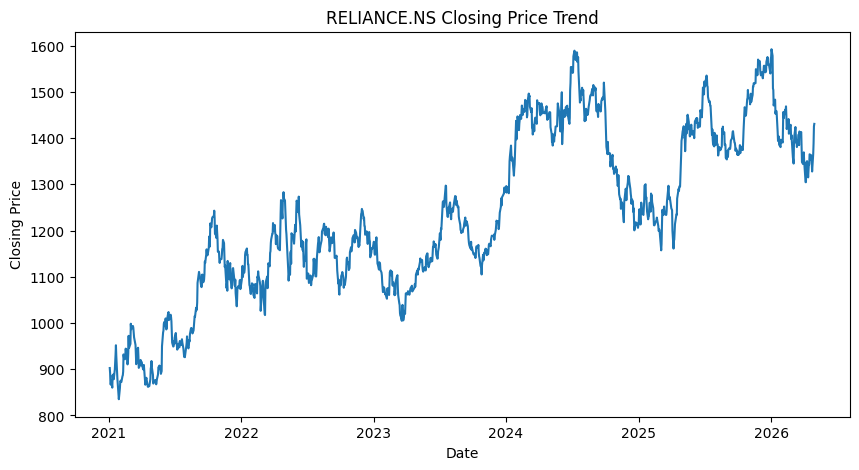

In [12]:
# Plot price trend for one stock

sample_stock="RELIANCE.NS"
stock_data=combined_data[combined_data["Symbol"]==sample_stock]

plt.figure(figsize=(10,5))
plt.plot(stock_data["Date"],stock_data["Close"])
plt.title(f"{sample_stock} Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

Log Return Distribution

This code shows us a picture (a chart) of how much stock was traded each day (volume). It helps us see if some days have much more trading than others.

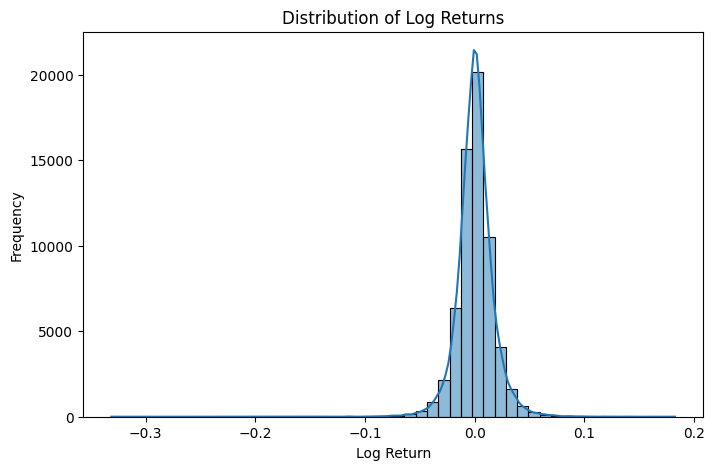

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(combined_data["Log_Return"],bins=50,kde=True)

plt.title("Distribution of Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

Trading Volume Distribution

This code creates a colorful grid (heatmap) that shows the relationships between different stock numbers, like Open, High, Low, Close, and Volume. Red means they move together, blue means they move opposite.

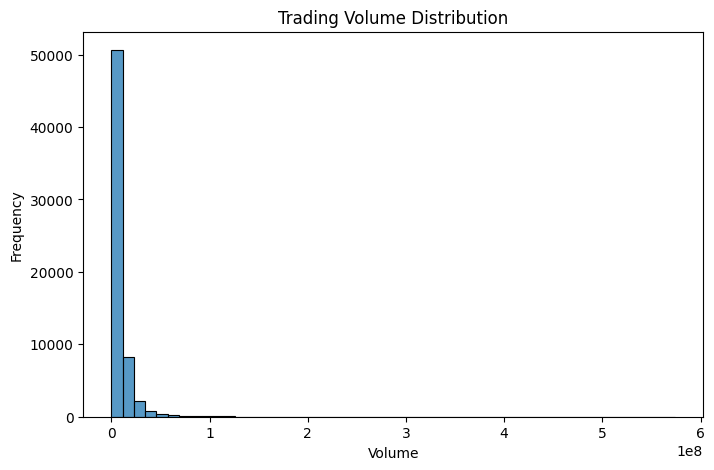

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(combined_data["Volume"],bins=50)

plt.title("Trading Volume Distribution")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

Correlation HeatMap

This code shows us a bar chart of the 10 most 'bouncy' stocks, meaning their prices change a lot. This helps us see which stocks are more risky.

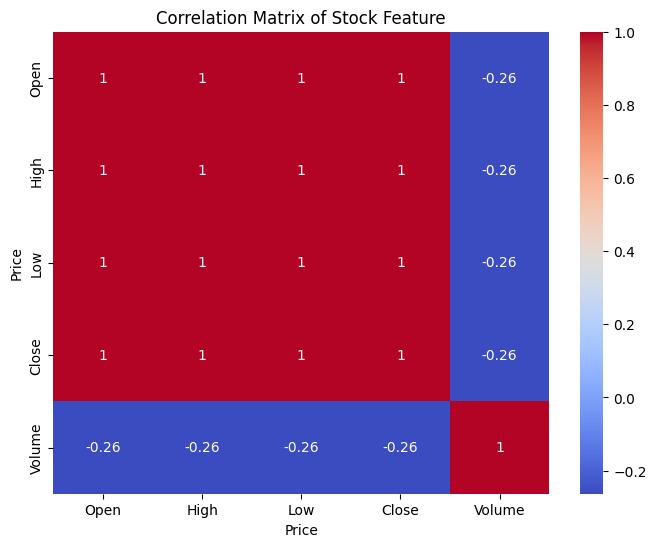

In [15]:
plt.figure(figsize=(8,6))
corr_matrix= combined_data[["Open","High","Low","Close","Volume"]].corr()
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix of Stock Feature")
plt.show()

Volatility Comparison

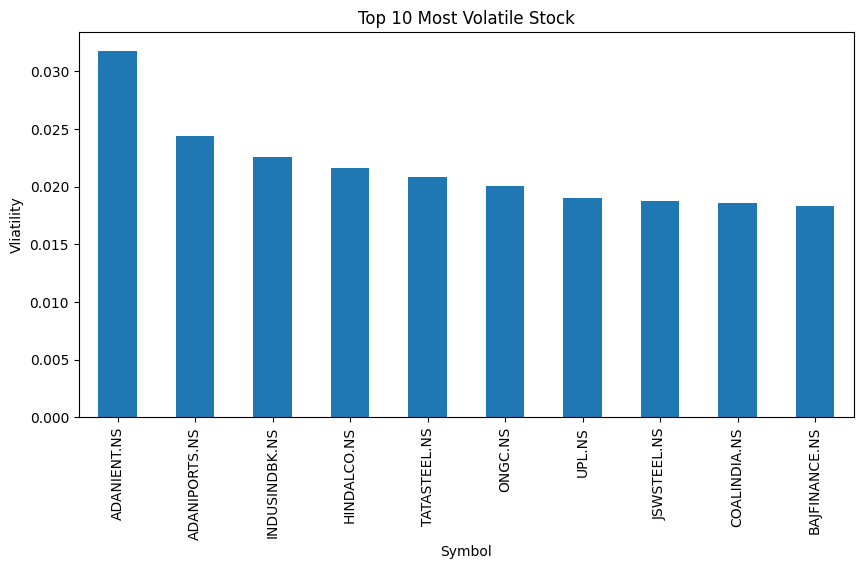

In [16]:
volatility= combined_data.groupby("Symbol")["Log_Return"].std().sort_values(ascending=False)
volatility.head(10).plot(kind="bar",figsize=(10,5))

plt.title("Top 10 Most Volatile Stock")
plt.ylabel("Vliatility")
plt.show()

Exploratory Data Analysis

This code shows us a simple line graph of how the closing price of one stock changes over time. It's a basic way to see the price trend.

Price Trend

This code makes a chart that shows how often different 'Log Returns' happen. It helps us understand the spread of daily stock changes.

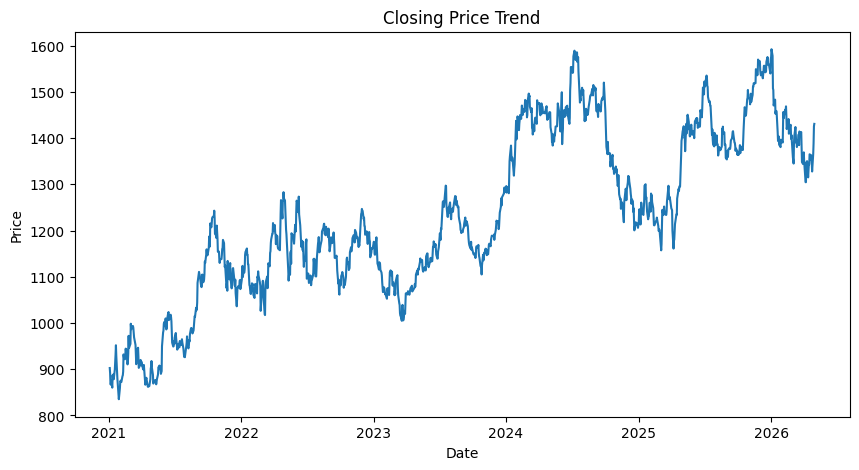

In [17]:
plt.figure(figsize=(10,5))

sample=combined_data[combined_data["Symbol"]=="RELIANCE.NS"]

plt.plot(sample["Date"],sample["Close"])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Return Distribution

This code draws a colorful map that shows how closely related different parts of the stock data are to each other, like opening price and closing price.

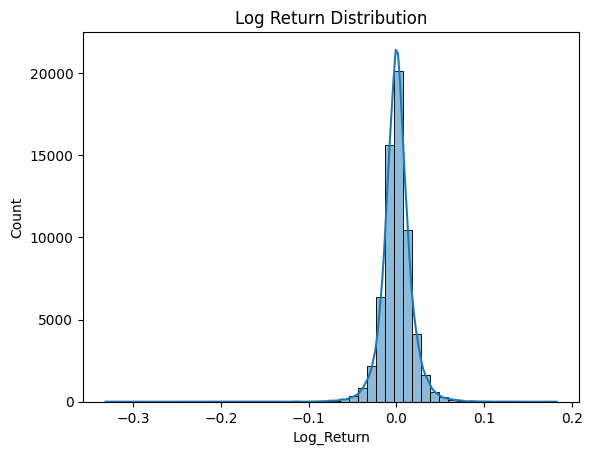

In [18]:
sns.histplot(combined_data["Log_Return"],bins=50,kde=True)
plt.title("Log Return Distribution")
plt.show()

Correlation between features

This code makes a bar chart to show which stocks change their prices the most (are most volatile). The taller the bar, the more 'bouncy' the stock.

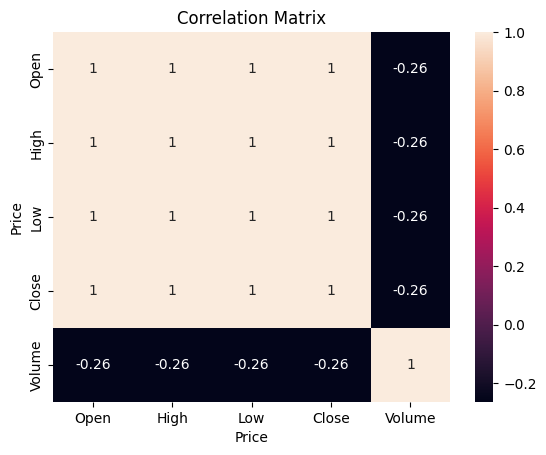

In [19]:
corr=combined_data[["Open","High","Low","Close","Volume"]].corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation Matrix")
plt.show()

Volatility by Stock

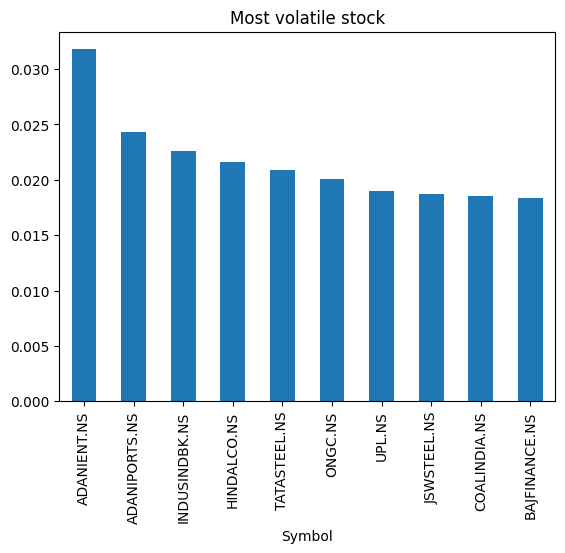

In [20]:
volatility=combined_data.groupby("Symbol")["Log_Return"].std()
volatility.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Most volatile stock")
plt.show()

Feature Engineering in Stock Market

Purpose It is crucial for converting raw stock market data into valuable indicators. These indicators enable machine learning models to effectively identify trends, momentum and volatilty in stock price.

Description

We are creating features that helps to capture different aespects of market behaviours such as trend direction,price momentum,volatility. Additionally , fundamental indicators such as ROE, earning per share (EPS) ,net profit growth and deb levels can provide insights into financial health of comapnies

In [21]:
import ta

def create_features(df):
    # Sorting the data
    df = df.sort_values("Date").copy()

    # 1. Returns and lagged returns
    df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
    for lag in [1, 2, 3, 5, 10, 20]:
        df[f"Return_LAG_{lag}"] = df["Log_Return"].shift(lag)

    # 2. Lagged market context from the full NIFTY 50 batch
    if "Market_Return" in df.columns:
        df["Market_Return_LAG_1"] = df["Market_Return"].shift(1)
        df["Market_Return_LAG_5"] = df["Market_Return"].rolling(5).mean().shift(1)
    else:
        df["Market_Return_LAG_1"] = 0.0
        df["Market_Return_LAG_5"] = 0.0

    # 2. Momentum and volatility features
    df["Momentum_5"] = df["Close"] / df["Close"].shift(5) - 1
    df["Momentum_10"] = df["Close"] / df["Close"].shift(10) - 1
    df["Momentum_20"] = df["Close"] / df["Close"].shift(20) - 1
    df["Volatility_10"] = df["Log_Return"].rolling(10).std().shift(1)
    df["Volatility_20"] = df["Log_Return"].rolling(20).std().shift(1)

    # 3. Moving averages and relative price position
    for window in [5, 10, 20, 50]:
        df[f"SMA_{window}"] = ta.trend.sma_indicator(df["Close"], window=window)
        df[f"EMA_{window}"] = ta.trend.ema_indicator(df["Close"], window=window)
        df[f"Close_to_SMA_{window}"] = df["Close"] / df[f"SMA_{window}"] - 1
        df[f"Close_to_EMA_{window}"] = df["Close"] / df[f"EMA_{window}"] - 1

    # 4. Intraday candle features
    df["Intraday_Range"] = (df["High"] - df["Low"]) / df["Close"]
    df["Body"] = (df["Close"] - df["Open"]) / df["Open"]
    df["Upper_Shadow"] = (df["High"] - df[["Close", "Open"]].max(axis=1)) / df["Close"]
    df["Lower_Shadow"] = (df[["Close", "Open"]].min(axis=1) - df["Low"]) / df["Close"]

    # 5. Volume features
    df["Volume_SMA_20"] = df["Volume"].rolling(window=20).mean()
    df["Volume_Ratio"] = df["Volume"] / df["Volume_SMA_20"]

    # 6. Technical indicators
    macd = ta.trend.MACD(df["Close"])
    df["MACD_Line"] = macd.macd()
    df["MACD_Signal"] = macd.macd_signal()
    df["MACD_Hist"] = macd.macd_diff()
    df["RSI_14"] = ta.momentum.rsi(df["Close"], window=14)
    df["RSI_7"] = ta.momentum.rsi(df["Close"], window=7)

    df["MFI"] = ta.volume.money_flow_index(
        df["High"], df["Low"], df["Close"], df["Volume"], window=14
    )

    df["ATR"] = ta.volatility.average_true_range(
        df["High"], df["Low"], df["Close"], window=14
    )
    df["ATR_Ratio"] = df["ATR"] / df["Close"]

    bb = ta.volatility.BollingerBands(df["Close"], window=20)
    df["BB_High"] = bb.bollinger_hband()
    df["BB_Low"] = bb.bollinger_lband()
    df["BB_Pos"] = (df["Close"] - df["BB_Low"]) / (df["BB_High"] - df["BB_Low"])
    df["BB_Width"] = (df["BB_High"] - df["BB_Low"]) / df["SMA_20"]

    df = df.dropna()
    return df


Input Symbol From User


In [22]:
# Combining all individual stock dataset into a single DataFrame
combined_data = pd.concat(stock_datasets, ignore_index=True)

# Converting the Date column to datetime format for proper time-series operations
combined_data["Date"] = pd.to_datetime(combined_data["Date"])


market_context = combined_data.sort_values(["Symbol", "Date"]).copy()

# Calculating log returns for each stock
market_context["Component_Log_Return"] = market_context.groupby("Symbol")["Close"].transform(
    lambda s: np.log(s / s.shift(1))
)

# Computing  the average market return for each date

market_context = (
    market_context.groupby("Date", as_index=False)["Component_Log_Return"]
    .mean()
    .rename(columns={"Component_Log_Return": "Market_Return"})
)

# Taking input from user

user_input_symbol = input("Enter a NIFTY 50 stock ticker symbol")

if not user_input_symbol.endswith(".NS"):
    user_input_symbol += ".NS"

stock_data = combined_data[combined_data["Symbol"] == user_input_symbol].copy()
stock_data = stock_data.merge(market_context, on="Date", how="left")

if stock_data.empty:
    print(f"No data found for {user_input_symbol}")
else:
    print(f"Running all models for {user_input_symbol}")
    print("Market context features added.")


Enter a NIFTY 50 stock ticker symbolTCS
Running all models for TCS.NS
Market context features added.


 Model Training Setup

In this step, I am creating the common setup that will be used for all machine learning models.

This code does a few important things:

a. creating  model_results to store evaluation scores

b. createing trained_models to save trained models

c. defines the featuring columns used for prediction

d. prepares the dataset for training and testing

e. converts predicted returns back into predicted closing prices

f.evaluates each model using RMSE, MAE, and RA^2

g. supports hyperparameter tuning using time-series cross-validation

This makes the later model cells cleaner, because I can reuse the same functions instead of writing the same steps again and again.

Main functions in this cell

1. prepare_regression_dataset()
  Prepares the features, target column, and train-test split

2.  target_to_close()  
  Converts model predictions into actual forecast-horizon closing prices

 3. evaluate_and_store_model()  
  Calculates model performance and saves the result

  4. `tune_model()`  
  Performs hyperparameter tuning using GridSearchCV

  5. fit_model()
  Trains a model directly without tuning

  6. train_and_evaluate()  
  Runs the full process: train, predict, evaluate, and store results

This cell only sets up the workflow.  
The actual models will be trained in the next steps.


In [23]:
import joblib
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reset results so old one-day/state scores do not pollute the comparison table.
model_results = []
trained_models = {}

# Default single-model horizon. The final leaderboard also tests next-day and one-month horizons.
# The naive baseline is still fair: it predicts the close will stay unchanged over the same horizon.
FORECAST_HORIZON = 5
TARGET_MODE = "return"
ENABLE_HYPERPARAM_TUNING = True
TIME_SERIES_SPLITS = 4

DEFAULT_FEATURE_COLUMNS = [
    "Log_Return",
    "Market_Return_LAG_1", "Market_Return_LAG_5",
    "Return_LAG_1", "Return_LAG_2", "Return_LAG_3", "Return_LAG_5", "Return_LAG_10", "Return_LAG_20",
    "Momentum_5", "Momentum_10", "Momentum_20",
    "Volatility_10", "Volatility_20",
    "Close_to_SMA_5", "Close_to_SMA_10", "Close_to_SMA_20", "Close_to_SMA_50",
    "Close_to_EMA_5", "Close_to_EMA_10", "Close_to_EMA_20", "Close_to_EMA_50",
    "Intraday_Range", "Body", "Upper_Shadow", "Lower_Shadow", "Volume_Ratio",
    "MACD_Line", "MACD_Signal", "MACD_Hist", "RSI_14", "RSI_7", "MFI",
    "ATR_Ratio", "BB_Pos", "BB_Width"
]

# Function to update model results (avoids duplicate entries)

def _upsert_model_result(name, rmse, mae, r2, directional_accuracy=None):
    global model_results

    # Removing previous entry for the same model
    model_results = [row for row in model_results if row.get("Model") != name]

     # Store updated metrics
    row = {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}
    if directional_accuracy is not None:
        row["Directional_Accuracy"] = directional_accuracy
    model_results.append(row)


# Prepare dataset for regression modeling
def prepare_regression_dataset(df, feature_columns=None, target_mode=TARGET_MODE, train_frac=0.8):

     # Use default features if none provided
    feature_columns = feature_columns or DEFAULT_FEATURE_COLUMNS

    df = df.copy()

     # Ensure proper datetime format and sort chronologically
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

     # Check if required features exist
    missing_features = [col for col in feature_columns if col not in df.columns]

    # Attempt to generate missing features dynamically
    if missing_features:
        if "create_features" in globals():
            df = create_features(df)
            missing_features = [col for col in feature_columns if col not in df.columns]
        if missing_features:
            raise KeyError(f"Missing feature columns: {missing_features}")

    # Shift ensures prediction is for future values
    df["Target_Close_Next_Day"] = df["Close"].shift(-FORECAST_HORIZON)

     # Calculate return-based target
    df["Target_Return_Next_Day"] = (df["Target_Close_Next_Day"] / df["Close"]) - 1.0

    required_columns = feature_columns + ["Target_Close_Next_Day", "Target_Return_Next_Day", "Close", "Date"]

     # Remove rows with missing values
    df = df.dropna(subset=required_columns).reset_index(drop=True)


     # Select target column
    target_col = "Target_Return_Next_Day" if target_mode == "return" else "Target_Close_Next_Day"

     # Split dataset into training and testing sets (time-based split)
    split = int(len(df) * train_frac)

    X = df[feature_columns]
    y = df[target_col]

     # Store metadata for evaluation
    meta = {
        "target_mode": target_mode,
        "target_col": target_col,
        "forecast_horizon": FORECAST_HORIZON,
        "dates_train": df.loc[: split - 1, "Date"].reset_index(drop=True),
        "dates_test": df.loc[split:, "Date"].reset_index(drop=True),
        "current_close_train": df.loc[: split - 1, "Close"].reset_index(drop=True),
        "current_close_test": df.loc[split:, "Close"].reset_index(drop=True),
        "actual_close_train": df.loc[: split - 1, "Target_Close_Next_Day"].reset_index(drop=True),
        "actual_close_test": df.loc[split:, "Target_Close_Next_Day"].reset_index(drop=True),
    }

    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:], meta


# Convert predicted return into actual predicted closing price
def target_to_close(current_close, predicted_target, target_mode):
    current_close = np.asarray(current_close).reshape(-1)
    predicted_target = np.asarray(predicted_target).reshape(-1)

    # If predicting returns, convert back to price
    if target_mode == "return":
        return current_close * (1.0 + predicted_target)
    return predicted_target

# Calculate directional accuracy whether model predicts correct trend direction
def compute_directional_accuracy(actual_returns, predicted_returns):
    actual_sign = np.sign(np.asarray(actual_returns).reshape(-1))
    predicted_sign = np.sign(np.asarray(predicted_returns).reshape(-1))
    return np.mean(actual_sign == predicted_sign)


# Evaluate model performance and store results
def evaluate_and_store_model(name, model, actual_close, predicted_close, predicted_target=None, current_close=None):
    actual_close = np.asarray(actual_close).reshape(-1)
    predicted_close = np.asarray(predicted_close).reshape(-1)


    # Compute evaluation metrics
    rmse = np.sqrt(mean_squared_error(actual_close, predicted_close))
    mae = mean_absolute_error(actual_close, predicted_close)
    r2 = r2_score(actual_close, predicted_close)

    # Compute directional accuracy if return predictions are available
    directional_accuracy = None
    if predicted_target is not None and current_close is not None:
        actual_returns = np.asarray(actual_close) / np.asarray(current_close).reshape(-1) - 1.0
        directional_accuracy = compute_directional_accuracy(actual_returns, predicted_target)

      # Store results
    _upsert_model_result(name, rmse, mae, r2, directional_accuracy)

     # Save trained model
    if model is not None:
        trained_models[name] = model


     # Print performance
    print(f"{name} Performance ({FORECAST_HORIZON}-trading-day horizon)")
    print("--------------------")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")
    if directional_accuracy is not None:
        print(f"Directional Accuracy: {directional_accuracy:.2%}")

    return rmse, mae, r2


# Perform hyperparameter tuning using time-series cross-validation
def tune_model(estimator, param_grid, X, y, scale_features=False, cv_splits=TIME_SERIES_SPLITS, scoring="neg_mean_squared_error"):
    estimator_to_fit = estimator
    search_grid = param_grid

     # Add scaling if required
    if scale_features:
        estimator_to_fit = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator),
        ])
        search_grid = {f"model__{key}": value for key, value in param_grid.items()}

     # TimeSeriesSplit ensures no future data leakage
    splitter = TimeSeriesSplit(n_splits=cv_splits)


    # Grid search for best parameters
    grid = GridSearchCV(
        estimator_to_fit,
        search_grid,
        cv=splitter,
        scoring=scoring,
        n_jobs=1,
        verbose=0,
        refit=True,
    )
    grid.fit(X, y)
    print(f"Tuned {estimator.__class__.__name__}: best params={grid.best_params_}")
    return grid.best_estimator_

# Fit model with optional feature scaling
def fit_model(estimator, X_train, y_train, scale_features=False):
    if scale_features:
        estimator = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator),
        ])
    estimator.fit(X_train, y_train)
    return estimator

# Train and evaluate complete pipeline

def train_and_evaluate(name, estimator, X_train, y_train, X_test, meta, param_grid=None, scale_features=False):
    if ENABLE_HYPERPARAM_TUNING and param_grid is not None:
        estimator = tune_model(estimator, param_grid, X_train, y_train, scale_features=scale_features)
    else:
        estimator = fit_model(estimator, X_train, y_train, scale_features=scale_features)

    predicted_target = estimator.predict(X_test)
    predicted_close = target_to_close(meta["current_close_test"], predicted_target, meta["target_mode"])
    evaluate_and_store_model(
        name, estimator, meta["actual_close_test"], predicted_close,
        predicted_target=predicted_target, current_close=meta["current_close_test"]
    )

    return estimator, predicted_close


Baseline Model Diagonostic

This cell checks whether the trained models are actually better than a simple naive baseline.

What is Naive Baseline model?

The naive baseline assumes that Tomorrow's closing price = Today's closing price

In this

1. We willverify stock_data exists
2. Recreate the same 80/20 train-test split
3. Build Naive prediction in test set
4. Calculate evaluation metrics


Why this matters ?

If the naive baseline performs as well as or better than your trained models, it usually means the models are not learning meaningful patterns and may just be copying recent price behavior.







This code uses a simple math model called 'Linear Regression' to try and guess the stock price in 5 days. It draws a straight line to see patterns. We check if it's better than our simple guess.

In [24]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare the same dataset used for other models
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(stock_data)

# Naive baseline:
# predict the forecast-horizon return as 0
# which means predicted future close = current close
actual_close = np.asarray(meta["actual_close_test"]).reshape(-1)
naive_pred_close = np.asarray(meta["current_close_test"]).reshape(-1)

# Calculate metrics
naive_rmse = np.sqrt(mean_squared_error(actual_close, naive_pred_close))
naive_mae = mean_absolute_error(actual_close, naive_pred_close)
naive_r2 = r2_score(actual_close, naive_pred_close)

# Store result
_upsert_model_result("Naive Baseline", naive_rmse, naive_mae, naive_r2)

print(f"Naive Baseline Performance ({FORECAST_HORIZON}-trading-day horizon)")
print("--------------------------")
print(f"RMSE: {naive_rmse:.4f}")
print(f"MAE : {naive_mae:.4f}")
print(f"R2  : {naive_r2:.4f}")

# Show current results table
results_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(results_df)


Naive Baseline Performance (5-trading-day horizon)
--------------------------
RMSE: 90.0911
MAE : 69.2288
R2  : 0.9022


,Model,RMSE,MAE,R2
0,Naive Baseline,90.091104,69.228821,0.902151


***Linear Regression Model***

**Description**

The system trains a linear regression model using historical stock data. Technical indicators such as moving averages, RSI , lag prices and logs are generated during feature engineering. The model predicts the 5-trading-day-ahead closing price based on current market featues.The dataset is divided into training and testing sets to evalaute performance using RMSE (Root Mean Squared Error)

NOTE: RMSE measures predction accuracy. Lower RMSE better is the model



In [25]:
from sklearn.linear_model import LinearRegression

# feature columns for training
feature_columns = DEFAULT_FEATURE_COLUMNS

# Prepare dataset for training and testing
# This function:
# - sorts data by date (time-series safe)
# - creates target variables (future price/return)
# - splits into train and test sets

X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

# Train Linear Regression model and evaluating
lr_model, y_pred = train_and_evaluate(
    "Linear Regression",
    LinearRegression(),
    X_train,
    y_train,
    X_test,
    meta,
)

# Create a DataFrame to compare actual vs predicted values
results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": meta["actual_close_test"].values,
    "Predicted": y_pred,
})

print("\nLinear Regression sample predictions:")
print(results.head(10))

print("\nModel comparison:")
comparison_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df)

naive_rmse = comparison_df.loc[comparison_df["Model"] == "Naive Baseline", "RMSE"].values[0]
lr_rmse = comparison_df.loc[comparison_df["Model"] == "Linear Regression", "RMSE"].values[0]

if lr_rmse < naive_rmse:
    print("\nLinear Regression is doing better than the Naive Baseline.")
else:
    print("\nLinear Regression is not doing better than the Naive Baseline yet.")


Linear Regression Performance (5-trading-day horizon)
--------------------
RMSE: 105.2718
MAE : 82.8347
R2  : 0.8664
Directional Accuracy: 43.08%

Linear Regression sample predictions:
        Date       Actual    Predicted
0 2025-04-16  3287.970459  3200.518631
1 2025-04-17  3332.820801  3214.121470
2 2025-04-21  3328.470703  3239.486828
3 2025-04-22  3356.501953  3235.051815
4 2025-04-23  3338.330078  3315.803161
5 2025-04-24  3316.388184  3255.884696
6 2025-04-25  3338.909912  3308.538814
7 2025-04-28  3344.419678  3266.561222
8 2025-04-29  3330.017334  3303.972727
9 2025-04-30  3333.690430  3295.848912

Model comparison:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,Linear Regression,105.271843,82.834706,0.866396,0.43083



Linear Regression is not doing better than the Naive Baseline yet.


After rerunning, compare Linear Regression with the naive baseline. If it still does not beat the baseline, this usually means:

1.the relationship is not purely linear

2.stock prices are highly noisy

3.todayÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢s price is already a very strong simple benchmark

This suggests that a simple linear relationship may not be enough to capture short-term stock price movement.

It also shows that the Naive Baseline is a strong benchmark for this dataset.



***Ridge Regression***

Ridge Regression is a regularized version of Linear Regression that adds a penalty term to reduce overfitting. It is especially useful when features are highly correlated.

Why Ridge is Used in This Project?

1 Stock data contains many correlated technical indicators

2 Helps reduce overfitting

3 Improves generalization on unseen data


In [26]:
from sklearn.linear_model import Ridge


# feature columns for training
feature_columns = DEFAULT_FEATURE_COLUMNS

# Prepare dataset:
# - Creates lag-based features
# - Generates target (future return or price)
# - Splits data into train and test sets (time-series safe)
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

# Alpha controls regularization strength (higher = more penalty)
ridge_param_grid = {
    "alpha": [0.1, 1.0, 5.0, 10.0, 25.0, 50.0]
}

# Train Ridge model with:
# - Hyperparameter tuning (GridSearchCV)
# - Feature scaling (important for Ridge)

ridge_model, y_pred = train_and_evaluate(
    "Ridge",
    Ridge(),
    X_train,
    y_train,
    X_test,
    meta,
    param_grid=ridge_param_grid,
    scale_features=True,
)

# Create DataFrame for actual vs predicted values
results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": meta["actual_close_test"].values,
    "Predicted": y_pred,
})

print("\nRidge sample predictions:")
print(results.head(10))


print("\nModel comparison:")
comparison_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df)

naive_rmse = comparison_df.loc[comparison_df["Model"] == "Naive Baseline", "RMSE"].values[0]
ridge_rmse = comparison_df.loc[comparison_df["Model"] == "Ridge", "RMSE"].values[0]

if ridge_rmse < naive_rmse:
    print("\nRidge is doing better than the Naive Baseline.")
else:
    print("\nRidge is not doing better than the Naive Baseline yet.")


Tuned Ridge: best params={'model__alpha': 50.0}
Ridge Performance (5-trading-day horizon)
--------------------
RMSE: 97.1719
MAE : 76.3347
R2  : 0.8862
Directional Accuracy: 39.92%

Ridge sample predictions:
        Date       Actual    Predicted
0 2025-04-16  3287.970459  3200.022274
1 2025-04-17  3332.820801  3217.171050
2 2025-04-21  3328.470703  3235.948067
3 2025-04-22  3356.501953  3233.379855
4 2025-04-23  3338.330078  3317.242043
5 2025-04-24  3316.388184  3271.742048
6 2025-04-25  3338.909912  3322.778880
7 2025-04-28  3344.419678  3300.597467
8 2025-04-29  3330.017334  3344.060737
9 2025-04-30  3333.690430  3331.063069

Model comparison:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,Ridge,97.171920,76.334740,0.886165,0.399209
2,Linear Regression,105.271843,82.834706,0.866396,0.430830



Ridge is not doing better than the Naive Baseline yet.


***KNN Regression Model***

What is KNN Regression?

K-Nearest Neighbors (KNN) is a non-parametric algorithm that predicts values based on the average of the k nearest data points in the feature space.

 Why KNN is Used in This Project

1 Captures non-linear relationships in stock data

2 Does not assume any fixed equation (unlike Linear Regression)

3 Works well when patterns depend on similar historical condition



In [27]:
from sklearn.neighbors import KNeighborsRegressor

#  feature columns for training
feature_columns = DEFAULT_FEATURE_COLUMNS

# Prepare dataset:
# - Ensures time-series order
# - Creates target variables (future return/price)
# - Splits into training and testing sets
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

# Define parameter grid for KNN
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}

# Training KNN model
knn_model, y_pred = train_and_evaluate(
    "KNN Regression",
    KNeighborsRegressor(),
    X_train,
    y_train,
    X_test,
    meta,
    param_grid=knn_param_grid,
    scale_features=True,
)

#  DataFrame to compare actual vs predicted values
results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": meta["actual_close_test"].values,
    "Predicted": y_pred,
})

print("\nKNN sample predictions:")
print(results.head(10))

# Model Comparison
print("\nModel comparison:")
comparison_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df)

knn_rmse = comparison_df.loc[comparison_df["Model"] == "KNN Regression", "RMSE"].values[0]

if "Naive Baseline" in comparison_df["Model"].values:
    naive_rmse = comparison_df.loc[comparison_df["Model"] == "Naive Baseline", "RMSE"].values[0]
    if knn_rmse < naive_rmse:
        print("\nKNN is doing better than the Naive Baseline.")
    else:
        print("\nKNN is not doing better than the Naive Baseline.")

if "Linear Regression" in comparison_df["Model"].values:
    linear_rmse = comparison_df.loc[comparison_df["Model"] == "Linear Regression", "RMSE"].values[0]
    if knn_rmse < linear_rmse:
        print("KNN is doing better than Linear Regression.")
    else:
        print("KNN is not doing better than Linear Regression.")

if "Ridge" in comparison_df["Model"].values:
    ridge_rmse = comparison_df.loc[comparison_df["Model"] == "Ridge", "RMSE"].values[0]
    if knn_rmse < ridge_rmse:
        print("KNN is doing better than Ridge.")
    else:
        print("KNN is not doing better than Ridge.")


Tuned KNeighborsRegressor: best params={'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}
KNN Regression Performance (5-trading-day horizon)
--------------------
RMSE: 104.6037
MAE : 83.4747
R2  : 0.8681
Directional Accuracy: 44.27%

KNN sample predictions:
        Date       Actual    Predicted
0 2025-04-16  3287.970459  3203.592971
1 2025-04-17  3332.820801  3189.817032
2 2025-04-21  3328.470703  3183.206093
3 2025-04-22  3356.501953  3189.645672
4 2025-04-23  3338.330078  3299.991127
5 2025-04-24  3316.388184  3307.925660
6 2025-04-25  3338.909912  3254.428476
7 2025-04-28  3344.419678  3251.551104
8 2025-04-29  3330.017334  3264.501787
9 2025-04-30  3333.690430  3272.735729

Model comparison:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,Ridge,97.171920,76.334740,0.886165,0.399209
2,KNN Regression,104.603747,83.474748,0.868087,0.442688
3,Linear Regression,105.271843,82.834706,0.866396,0.430830



KNN is not doing better than the Naive Baseline.
KNN is doing better than Linear Regression.
KNN is not doing better than Ridge.


SVR (Support Vector Regression)

Description Support Vector Regression is a supervised machine learning model that predcits continuous values by finding an optimal boundary within a certain error margin. It is effective for both linear and non-linear data patterns. SVR uses features as input features to predcit the 5-trading-day-ahead closing price. Since svr is sensitive to feature scale , StandardScale is applied before training. The model is evalauted using RMSE,MAE aND R^2 square


In [28]:
from sklearn.svm import SVR

#feature columns for training
feature_columns = DEFAULT_FEATURE_COLUMNS

# Training dataset
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

# Defining parameter grid for SVR
# C: controls model complexity (higher = less regularization)
# epsilon: margin of tolerance (no penalty zone)
# gamma: controls influence of each data point
svr_param_grid = {
    "C": [1, 10, 50],
    "epsilon": [0.001, 0.01, 0.05],
    "gamma": ["scale", 0.01, 0.1],
}

# Training SVR model using RBF kernel (non-linear)
svr_model, y_pred = train_and_evaluate(
    "SVR",
    SVR(kernel="rbf"),
    X_train,
    y_train,
    X_test,
    meta,
    param_grid=svr_param_grid,
    scale_features=True,
)

# Create DataFrame for actual vs predicted values
results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": meta["actual_close_test"].values,
    "Predicted": y_pred,
})

# Display sample predictions
print("\nSample Predictions:")
print(results.head(10))


# Model Comparison
print("\nModel comparison:")
comparison_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df)

svr_rmse = comparison_df.loc[comparison_df["Model"] == "SVR", "RMSE"].values[0]

if "Naive Baseline" in comparison_df["Model"].values:
    naive_rmse = comparison_df.loc[comparison_df["Model"] == "Naive Baseline", "RMSE"].values[0]
    if svr_rmse < naive_rmse:
        print("\nSVR is doing better than the Naive Baseline.")
    else:
        print("\nSVR is not doing better than the Naive Baseline.")

if "Linear Regression" in comparison_df["Model"].values:
    linear_rmse = comparison_df.loc[comparison_df["Model"] == "Linear Regression", "RMSE"].values[0]
    if svr_rmse < linear_rmse:
        print("SVR is doing better than Linear Regression.")
    else:
        print("SVR is not doing better than Linear Regression.")

if "Ridge" in comparison_df["Model"].values:
    ridge_rmse = comparison_df.loc[comparison_df["Model"] == "Ridge", "RMSE"].values[0]
    if svr_rmse < ridge_rmse:
        print("SVR is doing better than Ridge.")
    else:
        print("SVR is not doing better than Ridge.")

if "KNN Regression" in comparison_df["Model"].values:
    knn_rmse = comparison_df.loc[comparison_df["Model"] == "KNN Regression", "RMSE"].values[0]
    if svr_rmse < knn_rmse:
        print("SVR is doing better than KNN.")
    else:
        print("SVR is not doing better than KNN.")


Tuned SVR: best params={'model__C': 1, 'model__epsilon': 0.05, 'model__gamma': 0.1}
SVR Performance (5-trading-day horizon)
--------------------
RMSE: 91.7637
MAE : 70.0756
R2  : 0.8985
Directional Accuracy: 56.52%

Sample Predictions:
        Date       Actual    Predicted
0 2025-04-16  3287.970459  3162.554084
1 2025-04-17  3332.820801  3188.051131
2 2025-04-21  3328.470703  3207.059190
3 2025-04-22  3356.501953  3202.290742
4 2025-04-23  3338.330078  3295.362905
5 2025-04-24  3316.388184  3274.113389
6 2025-04-25  3338.909912  3321.630131
7 2025-04-28  3344.419678  3309.329376
8 2025-04-29  3330.017334  3330.746867
9 2025-04-30  3333.690430  3336.344029

Model comparison:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,SVR,91.763662,70.075634,0.898484,0.565217
2,Ridge,97.171920,76.334740,0.886165,0.399209
3,KNN Regression,104.603747,83.474748,0.868087,0.442688
4,Linear Regression,105.271843,82.834706,0.866396,0.430830



SVR is not doing better than the Naive Baseline.
SVR is doing better than Linear Regression.
SVR is doing better than Ridge.
SVR is doing better than KNN.


In [29]:
from sklearn.ensemble import RandomForestRegressor

# feature columns for training
feature_columns = DEFAULT_FEATURE_COLUMNS

# Prepare dataset:
# - Maintains chronological order (important for time-series)
# - Creates future prediction targets
# - Splits into training and testing sets
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

# rf_param_grid = {
#     "n_estimators": [200, 400],
#     "max_depth": [6, 10, None],
#     "min_samples_leaf": [1, 3, 5],
# }

# Hyperparameter Tuning

# n_estimators: number of trees in the forest
# max_depth: maximum depth of each tree
# min_samples_leaf: minimum samples required at leaf node
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [5, 10],
}

#Model Training
rf_model, y_pred = train_and_evaluate(
    "Random Forest Regression",
    RandomForestRegressor(random_state=42, n_jobs=1),
    X_train,
    y_train,
    X_test,
    meta,
    param_grid=rf_param_grid,
)
# Create DataFrame for actual vs predicted values
results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": meta["actual_close_test"].values,
    "Predicted": y_pred,
})

print("\nSample Predictions:")
print(results.head(10))

#Model Comparison

print("\nModel comparison:")
comparison_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df)

rf_rmse = comparison_df.loc[comparison_df["Model"] == "Random Forest Regression", "RMSE"].values[0]

if "Naive Baseline" in comparison_df["Model"].values:
    naive_rmse = comparison_df.loc[comparison_df["Model"] == "Naive Baseline", "RMSE"].values[0]
    if rf_rmse < naive_rmse:
        print("\nRandom Forest is doing better than the Naive Baseline.")
    else:
        print("\nRandom Forest is not doing better than the Naive Baseline.")

if "Linear Regression" in comparison_df["Model"].values:
    linear_rmse = comparison_df.loc[comparison_df["Model"] == "Linear Regression", "RMSE"].values[0]
    if rf_rmse < linear_rmse:
        print("Random Forest is doing better than Linear Regression.")
    else:
        print("Random Forest is not doing better than Linear Regression.")

if "Ridge" in comparison_df["Model"].values:
    ridge_rmse = comparison_df.loc[comparison_df["Model"] == "Ridge", "RMSE"].values[0]
    if rf_rmse < ridge_rmse:
        print("Random Forest is doing better than Ridge.")
    else:
        print("Random Forest is not doing better than Ridge.")

if "KNN Regression" in comparison_df["Model"].values:
    knn_rmse = comparison_df.loc[comparison_df["Model"] == "KNN Regression", "RMSE"].values[0]
    if rf_rmse < knn_rmse:
        print("Random Forest is doing better than KNN.")
    else:
        print("Random Forest is not doing better than KNN.")

if "SVR" in comparison_df["Model"].values:
    svr_rmse = comparison_df.loc[comparison_df["Model"] == "SVR", "RMSE"].values[0]
    if rf_rmse < svr_rmse:
        print("Random Forest is doing better than SVR.")
    else:
        print("Random Forest is not doing better than SVR.")


Tuned RandomForestRegressor: best params={'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 400}
Random Forest Regression Performance (5-trading-day horizon)
--------------------
RMSE: 95.8312
MAE : 75.3414
R2  : 0.8893
Directional Accuracy: 43.87%

Sample Predictions:
        Date       Actual    Predicted
0 2025-04-16  3287.970459  3215.694904
1 2025-04-17  3332.820801  3233.068592
2 2025-04-21  3328.470703  3247.929930
3 2025-04-22  3356.501953  3222.653580
4 2025-04-23  3338.330078  3267.188054
5 2025-04-24  3316.388184  3251.560995
6 2025-04-25  3338.909912  3297.240611
7 2025-04-28  3344.419678  3289.417649
8 2025-04-29  3330.017334  3319.110541
9 2025-04-30  3333.690430  3331.304741

Model comparison:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,SVR,91.763662,70.075634,0.898484,0.565217
2,Random Forest Regression,95.831222,75.341380,0.889285,0.438735
3,Ridge,97.171920,76.334740,0.886165,0.399209
4,KNN Regression,104.603747,83.474748,0.868087,0.442688
5,Linear Regression,105.271843,82.834706,0.866396,0.430830



Random Forest is not doing better than the Naive Baseline.
Random Forest is doing better than Linear Regression.
Random Forest is doing better than Ridge.
Random Forest is doing better than KNN.
Random Forest is not doing better than SVR.


XGBoost Regressor

What is XGBoost?

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that:

1 Builds trees sequentially

2 Each new tree corrects errors of previous ones

3 Optimizes using gradient descent

Why XGBoost is Used in This Project?

1 Handles complex and non-linear stock patterns

2 Provides high accuracy and performance

3 Includes regularization to prevent overfitting

4 Efficient and scalable

In [30]:
from xgboost import XGBRegressor

#feature columns used for training
feature_columns = DEFAULT_FEATURE_COLUMNS

# Prepare dataset:
# -Maintains chronological order (time-series safe)
# - Creates future prediction targets (return/price)
# - Splits into training and testing sets
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

# Hyperparameter Tuning

# n_estimators: number of boosting rounds
# learning_rate: step size for each update
# max_depth: depth of trees (controls complexity)
# subsample & colsample_bytree: randomness to prevent overfitting
# min_child_weight: minimum weight for splitting
# reg_alpha & reg_lambda: regularization terms
xgb_param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05],
    "max_depth": [2, 3],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [3, 5],
    "reg_alpha": [0.1],
    "reg_lambda": [3.0, 5.0],
}

#  Model Training

xgb_model, y_pred = train_and_evaluate(
    "XGBoost Regression",
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
        tree_method="hist",
    ),
    X_train,
    y_train,
    X_test,
    meta,
    param_grid=xgb_param_grid,
)

# Create DataFrame for actual vs predicted values
results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": meta["actual_close_test"].values,
    "Predicted": y_pred,
})

print("\nSample Predictions:")
print(results.head(10))

# Model Comparison
print("\nModel comparison:")
comparison_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df)

xgb_rmse = comparison_df.loc[comparison_df["Model"] == "XGBoost Regression", "RMSE"].values[0]

if "Naive Baseline" in comparison_df["Model"].values:
    naive_rmse = comparison_df.loc[comparison_df["Model"] == "Naive Baseline", "RMSE"].values[0]
    if xgb_rmse < naive_rmse:
        print("\nXGBoost is doing better than the Naive Baseline.")
    else:
        print("\nXGBoost is not doing better than the Naive Baseline.")

if "Linear Regression" in comparison_df["Model"].values:
    linear_rmse = comparison_df.loc[comparison_df["Model"] == "Linear Regression", "RMSE"].values[0]
    if xgb_rmse < linear_rmse:
        print("XGBoost is doing better than Linear Regression.")
    else:
        print("XGBoost is not doing better than Linear Regression.")

if "Ridge" in comparison_df["Model"].values:
    ridge_rmse = comparison_df.loc[comparison_df["Model"] == "Ridge", "RMSE"].values[0]
    if xgb_rmse < ridge_rmse:
        print("XGBoost is doing better than Ridge.")
    else:
        print("XGBoost is not doing better than Ridge.")

if "KNN Regression" in comparison_df["Model"].values:
    knn_rmse = comparison_df.loc[comparison_df["Model"] == "KNN Regression", "RMSE"].values[0]
    if xgb_rmse < knn_rmse:
        print("XGBoost is doing better than KNN.")
    else:
        print("XGBoost is not doing better than KNN.")

if "SVR" in comparison_df["Model"].values:
    svr_rmse = comparison_df.loc[comparison_df["Model"] == "SVR", "RMSE"].values[0]
    if xgb_rmse < svr_rmse:
        print("XGBoost is doing better than SVR.")
    else:
        print("XGBoost is not doing better than SVR.")

if "Random Forest Regression" in comparison_df["Model"].values:
    rf_rmse = comparison_df.loc[comparison_df["Model"] == "Random Forest Regression", "RMSE"].values[0]
    if xgb_rmse < rf_rmse:
        print("XGBoost is doing better than Random Forest.")
    else:
        print("XGBoost is not doing better than Random Forest.")


Tuned XGBRegressor: best params={'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 3.0, 'subsample': 0.8}
XGBoost Regression Performance (5-trading-day horizon)
--------------------
RMSE: 98.6820
MAE : 76.7032
R2  : 0.8826
Directional Accuracy: 47.04%

Sample Predictions:
        Date       Actual    Predicted
0 2025-04-16  3287.970459  3212.535091
1 2025-04-17  3332.820801  3239.611399
2 2025-04-21  3328.470703  3244.568240
3 2025-04-22  3356.501953  3223.028313
4 2025-04-23  3338.330078  3300.837967
5 2025-04-24  3316.388184  3270.635785
6 2025-04-25  3338.909912  3317.733212
7 2025-04-28  3344.419678  3298.715625
8 2025-04-29  3330.017334  3334.497012
9 2025-04-30  3333.690430  3319.427179

Model comparison:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,SVR,91.763662,70.075634,0.898484,0.565217
2,Random Forest Regression,95.831222,75.341380,0.889285,0.438735
3,Ridge,97.171920,76.334740,0.886165,0.399209
4,XGBoost Regression,98.682030,76.703153,0.882600,0.470356
5,KNN Regression,104.603747,83.474748,0.868087,0.442688
6,Linear Regression,105.271843,82.834706,0.866396,0.430830



XGBoost is not doing better than the Naive Baseline.
XGBoost is doing better than Linear Regression.
XGBoost is not doing better than Ridge.
XGBoost is doing better than KNN.
XGBoost is not doing better than SVR.
XGBoost is not doing better than Random Forest.


**Gradient Boosting**

What is Gradient Boosting?

Gradient Boosting is an ensemble learning technique that:

1 Builds models sequentially

2 Each new model corrects the errors of previous ones

3 Optimizes prediction using gradient descent

Why Gradient Boosting is Used in This Project?

1 Captures complex, non-linear relationships in stock data
2 Improves prediction accuracy step by step
3 Reduces both bias and variance

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

#  feature columns for training

feature_columns = DEFAULT_FEATURE_COLUMNS

# Prepare dataset:
# - Ensures chronological order (important for time-series data)
# - Creates future prediction targets (return or price)
# - Splits data into training and testing sets

X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

# Hyperparameter Tuning
# n_estimators: number of boosting stages (trees)
# learning_rate: contribution of each tree
# max_depth: depth of individual trees (controls complexity)
# subsample: fraction of samples used for each tree (adds randomness)
# min_samples_leaf: minimum samples in leaf node (reduces overfitting)
# max_features: number of features considered at each split
gb_param_grid = {
    "n_estimators": [150, 250],
    "learning_rate": [0.03, 0.05],
    "max_depth": [1, 2],
    "subsample": [0.8, 0.9],
    "min_samples_leaf": [5, 10],
    "max_features": ["sqrt"],
}

# Model Training
gb_model, y_pred = train_and_evaluate(
    "Gradient Boosting Regression",
    GradientBoostingRegressor(random_state=42),
    X_train,
    y_train,
    X_test,
    meta,
    param_grid=gb_param_grid,
)

#Create DataFrame for actual vs predicted values

results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": meta["actual_close_test"].values,
    "Predicted": y_pred,
})

print("\nSample Predictions:")
print(results.head(10))


Tuned GradientBoostingRegressor: best params={'learning_rate': 0.03, 'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 150, 'subsample': 0.9}
Gradient Boosting Regression Performance (5-trading-day horizon)
--------------------
RMSE: 93.4103
MAE : 72.4324
R2  : 0.8948
Directional Accuracy: 44.27%

Sample Predictions:
        Date       Actual    Predicted
0 2025-04-16  3287.970459  3182.037411
1 2025-04-17  3332.820801  3204.414326
2 2025-04-21  3328.470703  3226.464345
3 2025-04-22  3356.501953  3214.885982
4 2025-04-23  3338.330078  3298.397873
5 2025-04-24  3316.388184  3287.502099
6 2025-04-25  3338.909912  3329.390316
7 2025-04-28  3344.419678  3326.593892
8 2025-04-29  3330.017334  3353.069842
9 2025-04-30  3333.690430  3336.425081


***ARIMA MODEL***



ARIMA stands for AutoRegressive Integrated Moving Average. It is a classical time-series forecasting model that uses past observations of a variable to predict future values. ARIMA is defined by three parameters p,d and q where p represents the autoregressive order , d is degree of differencing and q is the moving average order.

ARIMA is applied to the historical closing prices of a selected stock. The data is divided into training and testing sets and the model forecast the closing price for the test period . Model performance is evaluated using RMSE, MAE, R^2 Score




In [33]:
from statsmodels.tsa.arima.model import ARIMA

# Re-apply create_features to stock_data and handle NaNs for ARIMA
# Ensure 'Date' column is datetime and sorted before creating features and dropping NaNs
processed_stock_data_arima = stock_data.copy()
processed_stock_data_arima["Date"] = pd.to_datetime(processed_stock_data_arima["Date"])
processed_stock_data_arima = processed_stock_data_arima.sort_values("Date").reset_index(drop=True)
processed_stock_data_arima = create_features(processed_stock_data_arima)
processed_stock_data_arima = processed_stock_data_arima.dropna().reset_index(drop=True)

close_series_full = processed_stock_data_arima["Close"]

if len(close_series_full) < 30:
    print("Not enough data to train ARIMA model.")
else:
    # Use 80% for training, 20% for testing for ARIMA
    split_point = int(len(close_series_full) * 0.8)
    train_arima = close_series_full.iloc[:split_point]
    test_arima = close_series_full.iloc[split_point:]

    arima_model = ARIMA(train_arima, order=(5, 1, 0)) # Using a common order (p, d, q)
    arima_fitted = arima_model.fit()

    # Forecast for the test period
    arima_forecast = arima_fitted.forecast(steps=len(test_arima))

    # Evaluate and store results
    evaluate_and_store_model(f"ARIMA ({user_input_symbol})", arima_fitted, test_arima, arima_forecast)

    results = pd.DataFrame({
        "Actual": test_arima.values,
        "Predicted": arima_forecast.values
    })

    print("\nSample Predictions:")
    print(results.head(10))


ARIMA (TCS.NS) Performance (5-trading-day horizon)
--------------------
RMSE: 342.2554
MAE : 255.0067
R2  : -0.4124

Sample Predictions:
        Actual    Predicted
0  3298.989990  3202.625903
1  3287.970459  3202.182959
2  3332.820801  3201.488999
3  3328.470703  3201.394406
4  3356.501953  3201.480985
5  3338.330078  3201.498462
6  3316.388184  3201.514270
7  3338.909912  3201.523384
8  3344.419678  3201.522843
9  3330.017334  3201.521688


***Prophet***



Prophet is a time series forecasting model developed for handling trend and seasonal patterns in sequential data. It works by decomposing the time series into components such as trend, seasonality and residual effect. Prophet is easy to use and performs well on many real-world forecasting tasks.

In this project, Prophet is applied to the historical closing prices of a selected stock. Data is converted into format required for prophet where data column is renames as ds and closing price as y.Model is trained on training data and used to forecasr the test period. Model performance is evaluated using RMSE and MAE and R^2 score

In [34]:
# Uncomment to install if not already available
# !pip install prophet

from prophet import Prophet

# Re-apply create_features to stock_data and handle NaNs for Prophet
# Ensure 'Date' column is datetime and sorted before creating features and dropping NaNs
processed_stock_data_prophet = stock_data.copy()
processed_stock_data_prophet["Date"] = pd.to_datetime(processed_stock_data_prophet["Date"])
processed_stock_data_prophet = processed_stock_data_prophet.sort_values("Date").reset_index(drop=True)
processed_stock_data_prophet = create_features(processed_stock_data_prophet)
processed_stock_data_prophet = processed_stock_data_prophet.dropna().reset_index(drop=True)

prophet_data = processed_stock_data_prophet[["Date", "Close"]].copy().rename(columns={"Date": "ds", "Close": "y"})

if len(prophet_data) < 30:
    print("Not enough data to train Prophet Model")
else:
    split = int(len(prophet_data) * 0.8)
    train = prophet_data[:split]
    test = prophet_data[split:]

    prophet_model = Prophet()
    prophet_model.fit(train)

    future = test[["ds"]].copy()
    forecast = prophet_model.predict(future)

    y_pred = forecast["yhat"].values
    y_test = test["y"].values

    evaluate_and_store_model(f"Prophet ({user_input_symbol})", prophet_model, y_test, y_pred)

    results = pd.DataFrame({
        "Date": test["ds"].values,
        "Actual": y_test,
        "Predicted": y_pred
    })

    print("\nSample Predictions:")
    print(results.head(10))


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet (TCS.NS) Performance (5-trading-day horizon)
--------------------
RMSE: 287.6095
MAE : 242.2025
R2  : 0.0026

Sample Predictions:
        Date       Actual    Predicted
0 2025-04-23  3298.989990  3338.203380
1 2025-04-24  3287.970459  3333.925346
2 2025-04-25  3332.820801  3333.036773
3 2025-04-28  3328.470703  3325.017348
4 2025-04-29  3356.501953  3319.270980
5 2025-04-30  3338.330078  3322.700938
6 2025-05-02  3316.388184  3320.377746
7 2025-05-05  3338.909912  3313.648712
8 2025-05-06  3344.419678  3307.546118
9 2025-05-07  3330.017334  3310.259951


***LSTM Model***



LSTM stands for Long Short-Term Memory.It is a type of recurrent neutral network designed for sequential data adn time-series forecasting.LSTM can remember past information over long periods, which make it useful for stock price prediction where previous price movements may infulence furture prices.

In this project, the LSTM model uses historical closing prices to create sequences of past observations. These sequences is used to train the model to predict the next day  choding price. The day is scaled before training, reshapend into 3D format required by LSTM and then divided into training and testing sets. Model oerformance is evalauted using RMSE,MAE and R^2 score.





In [35]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

feature_columns = DEFAULT_FEATURE_COLUMNS
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

feature_scaler = MinMaxScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)
y_train_scaled = target_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test.to_numpy().reshape(-1, 1)).flatten()

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all_scaled = np.concatenate([y_train_scaled, y_test_scaled])


def create_sequences(X, y, time_step):
    Xs, ys = [], []
    for i in range(time_step, len(X)):
        Xs.append(X[i - time_step : i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def split_sequence_sets(X_scaled, y_scaled, time_step, train_size):
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_step)
    seq_test_start = train_size - time_step
    return (
        X_seq[:seq_test_start],
        y_seq[:seq_test_start],
        X_seq[seq_test_start:],
        y_seq[seq_test_start:],
    )


def build_lstm_model(time_step, n_features, units, dropout):
    model = Sequential([
        Input(shape=(time_step, n_features)),
        LSTM(units, return_sequences=True),
        Dropout(dropout),
        LSTM(max(units // 2, 16), return_sequences=False),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model


lstm_param_grid = {
    "time_step": [15, 20],
    "units": [32],
    "dropout": [0.1],
    "batch_size": [16],
    "epochs": [30],
}

best_config = None
best_val_loss = np.inf

for config in ParameterGrid(lstm_param_grid):
    X_train_seq, y_train_seq, X_test_seq, y_test_seq = split_sequence_sets(
        X_all_scaled,
        y_all_scaled,
        config["time_step"],
        len(X_train_scaled),
    )

    if len(X_train_seq) < 50 or len(X_test_seq) == 0:
        continue

    val_size = max(20, int(len(X_train_seq) * 0.15))
    X_fit = X_train_seq[:-val_size]
    y_fit = y_train_seq[:-val_size]
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]

    tf.keras.backend.clear_session()
    candidate_model = build_lstm_model(
        config["time_step"],
        X_train_seq.shape[2],
        config["units"],
        config["dropout"],
    )
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    )

    history = candidate_model.fit(
        X_fit,
        y_fit,
        validation_data=(X_val, y_val),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        verbose=0,
        callbacks=[early_stopping],
    )

    candidate_best_loss = float(np.min(history.history["val_loss"]))
    print(f"Checked LSTM config {config} -> best val_loss={candidate_best_loss:.6f}")

    if candidate_best_loss < best_val_loss:
        best_val_loss = candidate_best_loss
        best_config = config

if best_config is None:
    raise ValueError("LSTM tuning did not produce a valid configuration.")

print(f"Best LSTM config: {best_config}")

X_train_seq, y_train_seq, X_test_seq, y_test_seq = split_sequence_sets(
    X_all_scaled,
    y_all_scaled,
    best_config["time_step"],
    len(X_train_scaled),
)

final_model = build_lstm_model(
    best_config["time_step"],
    X_train_seq.shape[2],
    best_config["units"],
    best_config["dropout"],
)

final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = final_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.15,
    epochs=best_config["epochs"],
    batch_size=best_config["batch_size"],
    verbose=1,
    callbacks=[final_early_stopping],
)

pred_scaled = final_model.predict(X_test_seq, verbose=0).flatten()
pred_target = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
pred_close = target_to_close(meta["current_close_test"], pred_target, meta["target_mode"])
actual_close = meta["actual_close_test"].to_numpy()

rmse, mae, r2 = evaluate_and_store_model(
    f"LSTM ({user_input_symbol})",
    final_model,
    actual_close,
    pred_close,
)

print("LSTM Model Performance")
print("----------------------")
print("Stock:", user_input_symbol)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

results = pd.DataFrame({
    "Date": meta["dates_test"],
    "Actual": actual_close,
    "Predicted": pred_close,
})

print("\nSample Predictions:")
print(results.head(10))

Checked LSTM config {'batch_size': 16, 'dropout': 0.1, 'epochs': 30, 'time_step': 15, 'units': 32} -> best val_loss=1.257150
Checked LSTM config {'batch_size': 16, 'dropout': 0.1, 'epochs': 30, 'time_step': 20, 'units': 32} -> best val_loss=1.210199
Best LSTM config: {'batch_size': 16, 'dropout': 0.1, 'epochs': 30, 'time_step': 20, 'units': 32}
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.9393 - val_loss: 1.4398
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9316 - val_loss: 1.4098
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9222 - val_loss: 1.3950
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9170 - val_loss: 1.4462
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9090 - val_loss: 1.3196
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8538 - val_loss: 1.3030
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8702 - val_loss: 1.3100
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0

***Ensemble Model and Final Baseline Check***

This final cell blends the strongest stable models and checks whether the best model beats the naive baseline on the same forecast horizon.


In [36]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

feature_columns = DEFAULT_FEATURE_COLUMNS
X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=TARGET_MODE,
)

base_models = []

ridge_ens = fit_model(Ridge(alpha=10.0), X_train, y_train, scale_features=True)
base_models.append(("Ridge", ridge_ens, ridge_ens.predict(X_test)))

rf_ens = fit_model(
    RandomForestRegressor(
        n_estimators=500, max_depth=5, min_samples_leaf=10,
        random_state=42, n_jobs=1
    ),
    X_train,
    y_train,
)
base_models.append(("Random Forest", rf_ens, rf_ens.predict(X_test)))

gb_ens = fit_model(
    GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=2,
        min_samples_leaf=10, subsample=0.8, random_state=42
    ),
    X_train,
    y_train,
)
base_models.append(("Gradient Boosting", gb_ens, gb_ens.predict(X_test)))

et_ens = fit_model(
    ExtraTreesRegressor(
        n_estimators=500, max_depth=5, min_samples_leaf=10,
        random_state=42, n_jobs=1
    ),
    X_train,
    y_train,
)
base_models.append(("Extra Trees", et_ens, et_ens.predict(X_test)))

try:
    from xgboost import XGBRegressor
    xgb_ens = fit_model(
        XGBRegressor(
            n_estimators=300, learning_rate=0.03, max_depth=2,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
            reg_alpha=0.1, reg_lambda=5.0, objective="reg:squarederror",
            random_state=42, n_jobs=1, tree_method="hist"
        ),
        X_train,
        y_train,
    )
    base_models.append(("XGBoost", xgb_ens, xgb_ens.predict(X_test)))
except Exception as exc:
    print(f"Skipping XGBoost in ensemble: {exc}")

prediction_matrix = np.vstack([pred for _, _, pred in base_models])
weights = np.ones(prediction_matrix.shape[0]) / prediction_matrix.shape[0]
ensemble_target = np.average(prediction_matrix, axis=0, weights=weights)
ensemble_close = target_to_close(meta["current_close_test"], ensemble_target, meta["target_mode"])

evaluate_and_store_model(
    "Ensemble (Ridge+RF+GB+ET+XGB)",
    {name: model for name, model, _ in base_models},
    meta["actual_close_test"],
    ensemble_close,
    predicted_target=ensemble_target,
    current_close=meta["current_close_test"],
)

comparison_df = pd.DataFrame(model_results).sort_values("RMSE").reset_index(drop=True)
display(comparison_df)

best_model = comparison_df.iloc[0]
naive_rmse = comparison_df.loc[comparison_df["Model"] == "Naive Baseline", "RMSE"].values[0]
print(f"\nBest model: {best_model['Model']} with RMSE {best_model['RMSE']:.4f}")
if best_model["RMSE"] < naive_rmse:
    print(f"Best model beats the Naive Baseline by {naive_rmse - best_model['RMSE']:.4f} RMSE.")
else:
    print("No model beat the Naive Baseline on this run. For one-stock short-horizon prediction, that can happen; try another symbol or add market-index features.")


Ensemble (Ridge+RF+GB+ET+XGB) Performance (5-trading-day horizon)
--------------------
RMSE: 98.3225
MAE : 76.5783
R2  : 0.8835
Directional Accuracy: 45.45%


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,SVR,91.763662,70.075634,0.898484,0.565217
2,Gradient Boosting Regression,93.410282,72.432425,0.894808,0.442688
3,Random Forest Regression,95.831222,75.341380,0.889285,0.438735
4,LSTM (TCS.NS),96.079665,74.850124,0.888710,NaN
5,Ridge,97.171920,76.334740,0.886165,0.399209
6,Ensemble (Ridge+RF+GB+ET+XGB),98.322464,76.578322,0.883454,0.454545
7,XGBoost Regression,98.682030,76.703153,0.882600,0.470356
8,KNN Regression,104.603747,83.474748,0.868087,0.442688
9,Linear Regression,105.271843,82.834706,0.866396,0.430830



Best model: Naive Baseline with RMSE 90.0911
No model beat the Naive Baseline on this run. For one-stock short-horizon prediction, that can happen; try another symbol or add market-index features.


### **Comparing Best Model**

This section aggregates the performance metrics (RMSE, MAE, R²) from all trained models into a comparison table. It then sorts the models by RMSE to identify the best-performing algorithm and visualizes these metrics using bar charts. This comprehensive comparison helps in understanding which model provides the most accurate and reliable stock price predictions.

Model Comparison Table:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,Linear Regression,105.271843,82.834706,0.866396,0.430830
2,Ridge,97.171920,76.334740,0.886165,0.399209
3,KNN Regression,104.603747,83.474748,0.868087,0.442688
4,SVR,91.763662,70.075634,0.898484,0.565217
5,Random Forest Regression,95.831222,75.341380,0.889285,0.438735
6,XGBoost Regression,98.682030,76.703153,0.882600,0.470356
7,Gradient Boosting Regression,93.410282,72.432425,0.894808,0.442688
8,ARIMA (TCS.NS),342.255366,255.006733,-0.412386,NaN
9,Prophet (TCS.NS),287.609491,242.202472,0.002623,NaN


Models Ranked by RMSE:


,Model,RMSE,MAE,R2,Directional_Accuracy
0,Naive Baseline,90.091104,69.228821,0.902151,NaN
1,SVR,91.763662,70.075634,0.898484,0.565217
2,Gradient Boosting Regression,93.410282,72.432425,0.894808,0.442688
3,Random Forest Regression,95.831222,75.341380,0.889285,0.438735
4,LSTM (TCS.NS),96.079665,74.850124,0.888710,NaN
5,Ridge,97.171920,76.334740,0.886165,0.399209
6,Ensemble (Ridge+RF+GB+ET+XGB),98.322464,76.578322,0.883454,0.454545
7,XGBoost Regression,98.682030,76.703153,0.882600,0.470356
8,KNN Regression,104.603747,83.474748,0.868087,0.442688
9,Linear Regression,105.271843,82.834706,0.866396,0.430830



Naive Baseline was the top model. Selecting the second best model for further analysis:
Model Name : SVR
MAE        : 70.0756
RMSE       : 91.7637
R2 Score   : 0.8985


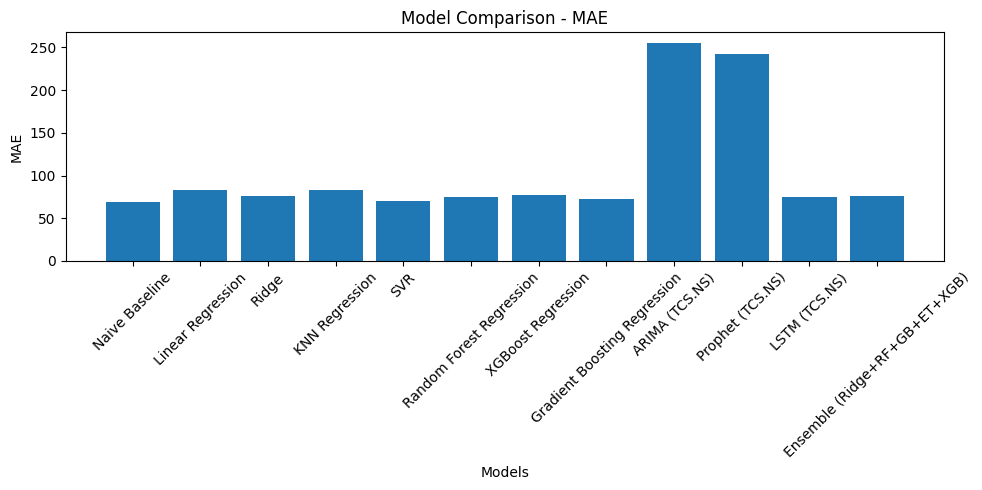

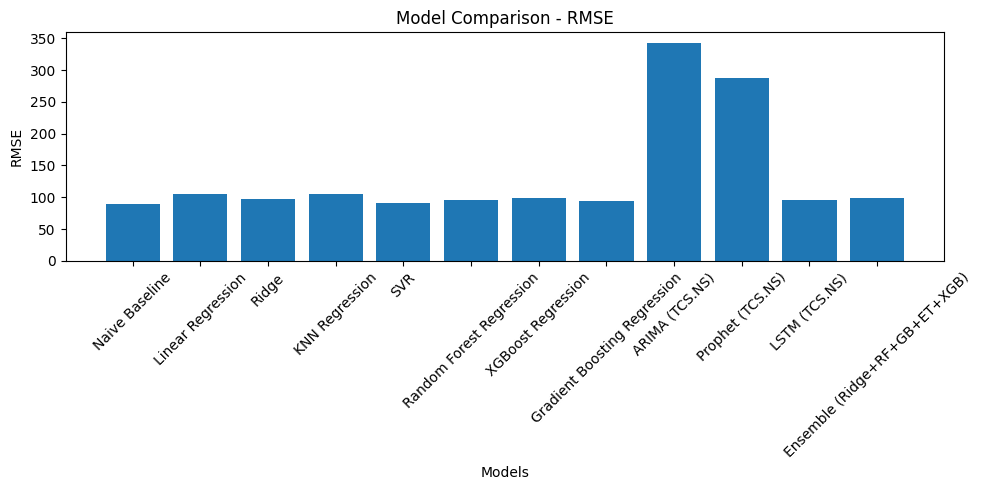

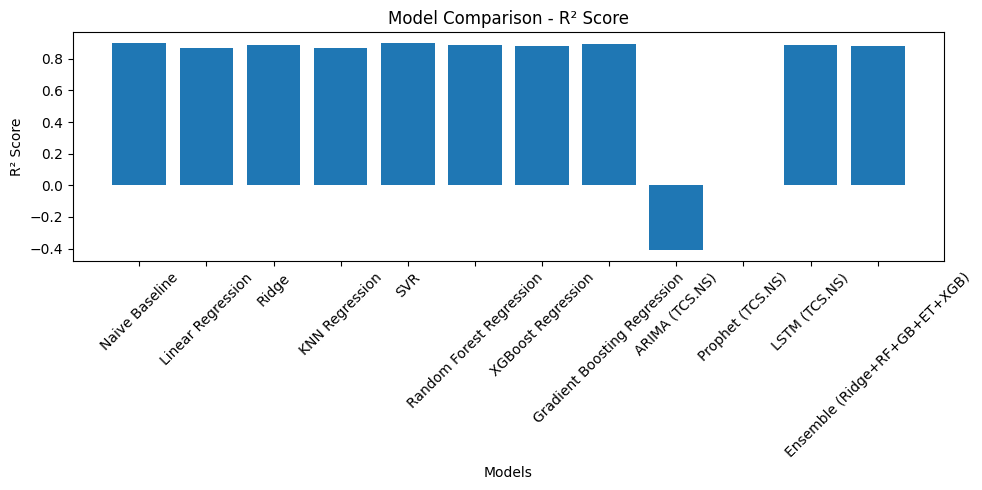


Conclusion:
The best performing model is SVR because it achieved the lowest RMSE.
Its MAE is 70.0756, RMSE is 91.7637, and R² score is 0.8985.



In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results to DataFrame
results_df = pd.DataFrame(model_results)
results_df.columns = [col.strip() for col in results_df.columns]

print("Model Comparison Table:")
display(results_df)
# Sort by RMSE
results_sorted = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print("Models Ranked by RMSE:")
display(results_sorted)

# Determine the best model, skipping "Naive Baseline" if it's ranked first
if not results_sorted.empty and results_sorted.iloc[0]["Model"] == "Naive Baseline":
    if len(results_sorted) > 1:
        best_model = results_sorted.iloc[1]  # Select the second best model
        print("\nNaive Baseline was the top model. Selecting the second best model for further analysis:")
    else:
        best_model = results_sorted.iloc[0] # Only Naive Baseline available, use it.
        print("\nOnly Naive Baseline model available. Using it for further analysis:")
else:
    best_model = results_sorted.iloc[0] # Select the top model
    print("\nBest Model Based on RMSE:")

print(f"Model Name : {best_model['Model']}")
print(f"MAE        : {best_model['MAE']:.4f}")
print(f"RMSE       : {best_model['RMSE']:.4f}")
print(f"R2 Score   : {best_model['R2']:.4f}")

# MAE Graph
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison - MAE")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# RMSE Graph
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison - RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# R2 Graph
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison - R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"""
Conclusion:
The best performing model is {best_model['Model']} because it achieved the lowest RMSE.
Its MAE is {best_model['MAE']:.4f}, RMSE is {best_model['RMSE']:.4f}, and R² score is {best_model['R2']:.4f}.
""")

### **Residual Analysis and Prediction Visualization**

This section performs a detailed analysis of the best-performing model's predictions by calculating residuals (Actual - Predicted values). It visualizes the actual vs. predicted closing prices over time, a scatter plot comparing actual and predicted values, and a residual error plot. These visualizations help in understanding the model's predictive accuracy, consistency, and potential biases.

Best Model Test Predictions:


,Date,Actual_Close,Predicted_Close,Residual
0,2025-04-16,3287.970459,3162.554084,125.416375
1,2025-04-17,3332.820801,3188.051131,144.769670
2,2025-04-21,3328.470703,3207.059190,121.411513
3,2025-04-22,3356.501953,3202.290742,154.211211
4,2025-04-23,3338.330078,3295.362905,42.967173
5,2025-04-24,3316.388184,3274.113389,42.274795
6,2025-04-25,3338.909912,3321.630131,17.279781
7,2025-04-28,3344.419678,3309.329376,35.090302
8,2025-04-29,3330.017334,3330.746867,-0.729533
9,2025-04-30,3333.690430,3336.344029,-2.653599


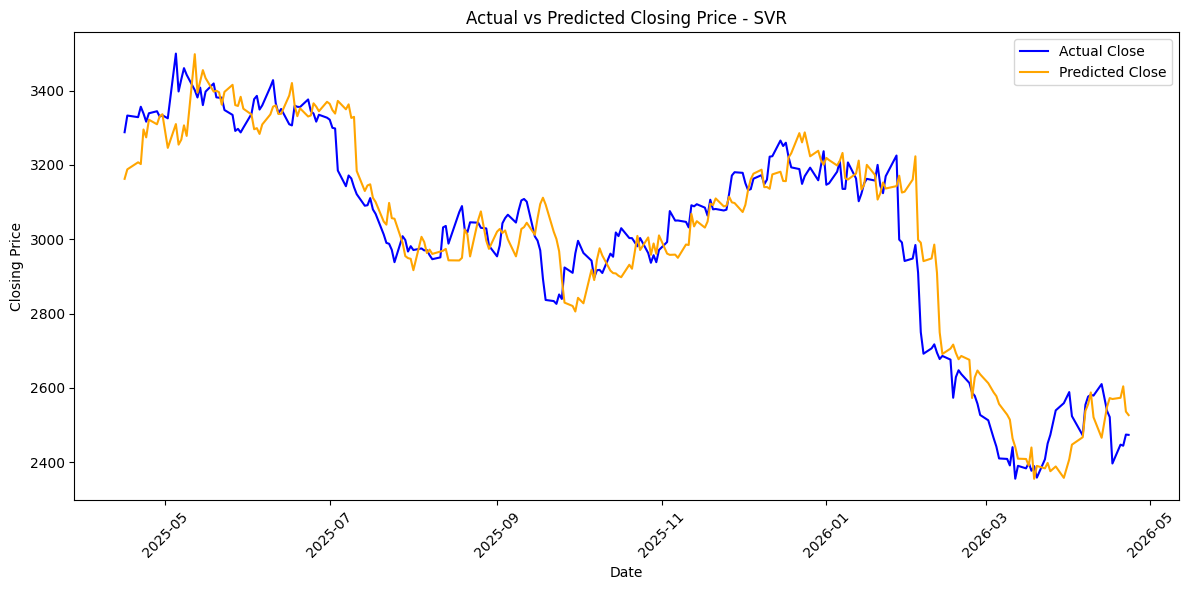

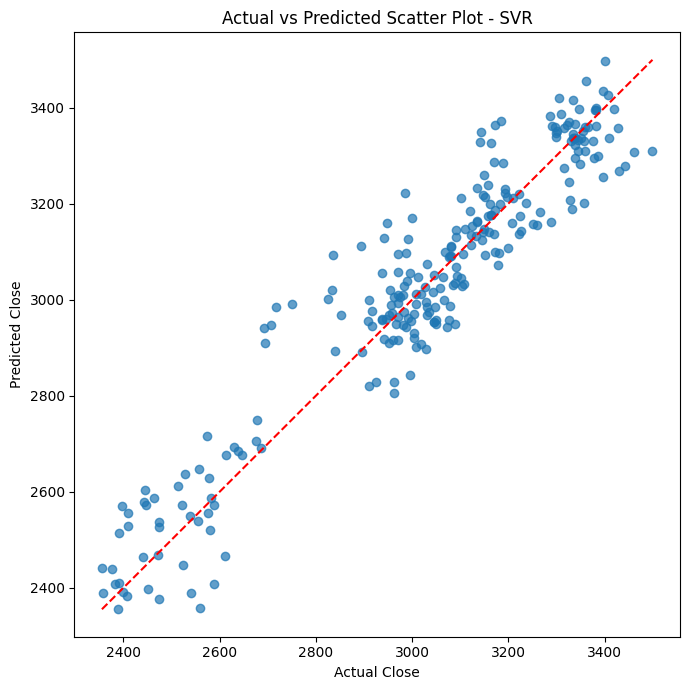

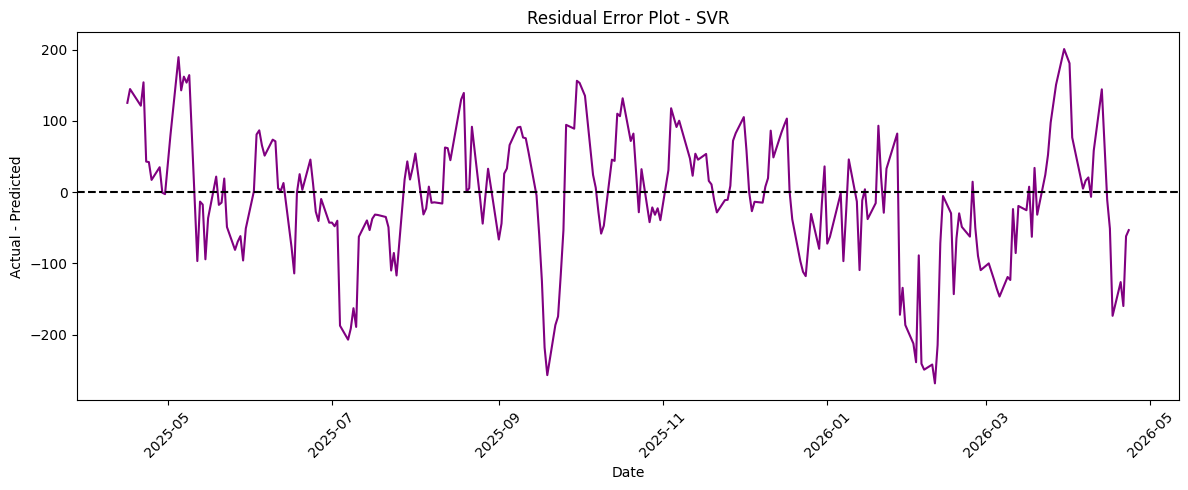

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "best_model" not in globals():
    raise NameError("Run the model comparison cell first so best_model is available.")

if "trained_models" not in globals() or len(trained_models) == 0:
    raise NameError("Run the model training cells first so trained_models is available.")

if "stock_data" not in globals() or stock_data.empty:
    raise NameError("Run the stock selection cell first so stock_data is available.")

best_model_name = best_model["Model"]
best_model_obj = trained_models.get(best_model_name)

if best_model_obj is None:
    raise ValueError(f"Trained model object for {best_model_name} not found.")

feature_columns = globals().get("DEFAULT_FEATURE_COLUMNS", ["Open", "High", "Low", "Close", "Volume", "Log_Return"])
target_mode = globals().get("TARGET_MODE", "return")

X_train, X_test, y_train, y_test, meta = prepare_regression_dataset(
    stock_data,
    feature_columns,
    target_mode=target_mode,
)

if "LSTM" in best_model_name:
    if "feature_scaler" not in globals() or "target_scaler" not in globals() or "best_config" not in globals():
        raise NameError("Run the LSTM training cell first so feature_scaler, target_scaler, and best_config are available.")

    time_step = int(best_config["time_step"])
    full_df = stock_data.copy()
    full_df["Date"] = pd.to_datetime(full_df["Date"])
    full_df = full_df.sort_values("Date").reset_index(drop=True)

    if "Log_Return" not in full_df.columns:
        full_df["Log_Return"] = np.log(full_df["Close"] / full_df["Close"].shift(1))

    missing_features = [col for col in feature_columns if col not in full_df.columns]
    if missing_features and "create_features" in globals():
        full_df = create_features(full_df)

    full_df["Target_Close_Next_Day"] = full_df["Close"].shift(-1)
    full_df["Target_Return_Next_Day"] = (full_df["Target_Close_Next_Day"] / full_df["Close"]) - 1.0
    full_df = full_df.dropna(subset=feature_columns + ["Target_Close_Next_Day", "Target_Return_Next_Day", "Close", "Date"]).reset_index(drop=True)

    split_index = int(len(full_df) * 0.8)

    X_all = full_df[feature_columns]
    y_all = full_df["Target_Return_Next_Day"] if target_mode == "return" else full_df["Target_Close_Next_Day"]

    X_all_scaled = feature_scaler.transform(X_all)
    y_all_scaled = target_scaler.transform(y_all.to_numpy().reshape(-1, 1)).flatten()

    X_seq, y_seq = [], []
    for i in range(time_step, len(X_all_scaled)):
        X_seq.append(X_all_scaled[i - time_step:i])
        y_seq.append(y_all_scaled[i])

    X_seq = np.array(X_seq)
    seq_test_start = split_index - time_step
    X_test_seq = X_seq[seq_test_start:]

    pred_scaled = best_model_obj.predict(X_test_seq, verbose=0).flatten()
    pred_target = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

    # Align arrays to the same length (LSTM test set may differ from meta test set)
    min_len = min(len(meta["current_close_test"]), len(pred_target))
    aligned_current_close = meta["current_close_test"].iloc[:min_len]
    aligned_pred_target = pred_target[:min_len]

    predicted_close = target_to_close(aligned_current_close, aligned_pred_target, target_mode)
else:
    pred_target = best_model_obj.predict(X_test)
    predicted_close = target_to_close(meta["current_close_test"], pred_target, target_mode)

actual_close = meta["actual_close_test"].to_numpy()
test_dates = pd.to_datetime(meta["dates_test"])

# Align actual_close to match predicted_close length
min_len = min(len(actual_close), len(predicted_close))
actual_close = actual_close[:min_len]
test_dates = test_dates.iloc[:min_len]
predicted_close = predicted_close[:min_len]

result_plot_df = pd.DataFrame({
    "Date": test_dates,
    "Actual_Close": actual_close,
    "Predicted_Close": predicted_close,
})
result_plot_df["Residual"] = result_plot_df["Actual_Close"] - result_plot_df["Predicted_Close"]

print("Best Model Test Predictions:")
display(result_plot_df.head(10))

# 1. Actual vs Predicted Line Graph
plt.figure(figsize=(12, 6))
plt.plot(result_plot_df["Date"], result_plot_df["Actual_Close"], label="Actual Close", color="blue")
plt.plot(result_plot_df["Date"], result_plot_df["Predicted_Close"], label="Predicted Close", color="orange")
plt.title(f"Actual vs Predicted Closing Price - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Scatter Plot of Actual vs Predicted
plt.figure(figsize=(7, 7))
plt.scatter(result_plot_df["Actual_Close"], result_plot_df["Predicted_Close"], alpha=0.7)
min_val = min(result_plot_df["Actual_Close"].min(), result_plot_df["Predicted_Close"].min())
max_val = max(result_plot_df["Actual_Close"].max(), result_plot_df["Predicted_Close"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.title(f"Actual vs Predicted Scatter Plot - {best_model_name}")
plt.xlabel("Actual Close")
plt.ylabel("Predicted Close")
plt.tight_layout()
plt.show()

# 3. Residual Error Plot
plt.figure(figsize=(12, 5))
plt.plot(result_plot_df["Date"], result_plot_df["Residual"], color="purple")
plt.axhline(0, color="black", linestyle="--")
plt.title(f"Residual Error Plot - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Forecast Profit/Loss and Recommendation**

This section leverages the best-performing model to forecast future stock prices and provide a trading recommendation (Buy, Sell, or Hold). Users input a buy date, sell/check date, buy price, and quantity. The system then projects future closing prices, calculates potential profit/loss per share and in total, and offers a recommendation based on predefined return thresholds. It also visualizes the historical data and forecasted trend.

Example input: buy date = 17-03-2026, sell/check date = 15-04-2026, buy price = 3520, quantity = 10
Enter buy date (YYYY-MM-DD or DD-MM-YYYY): 2026-03-17
Enter sell/check date within 31 days (YYYY-MM-DD or DD-MM-YYYY): 2026-03-20
Enter your buy price: 3400
Enter quantity (press Enter for 1): 4
Forecast Summary
----------------
Best model used     : SVR
Effective buy date  : 2026-03-17
Requested sell date : 2026-03-20
Buy price           : 3400.00
Quantity            : 4
Forecasted sell px  : 2391.27
Expected return %   : -29.67%
Per share P/L       : -1008.73
Total P/L           : -4034.93
Recommendation      : Sell
Reason              : The model expects downside from the entered buy price over the selected period.

Day-Wise Forecast
-----------------


/tmp/ipykernel_4876/604399621.py:98: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  buy_date_requested = pd.to_datetime(buy_date_input, dayfirst=True)
/tmp/ipykernel_4876/604399621.py:99: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  sell_date_requested = pd.to_datetime(sell_date_input, dayfirst=True)


,Date,Predicted_Close,Buy_Price,Per_Share_PL,Total_PL,Return_Pct,Action
0,2026-03-18,2391.56,3400.0,-1008.44,-4033.78,-29.66,Sell
1,2026-03-19,2391.41,3400.0,-1008.59,-4034.35,-29.66,Sell
2,2026-03-20,2391.27,3400.0,-1008.73,-4034.93,-29.67,Sell



Simple Explanation
------------------
On 2026-03-18, predicted close is 2391.56. Compared with buy price 3400.00, this means loss of 1008.44 per share and 4033.78 total for quantity 4. Suggested action: Sell.
On 2026-03-19, predicted close is 2391.41. Compared with buy price 3400.00, this means loss of 1008.59 per share and 4034.35 total for quantity 4. Suggested action: Sell.
On 2026-03-20, predicted close is 2391.27. Compared with buy price 3400.00, this means loss of 1008.73 per share and 4034.93 total for quantity 4. Suggested action: Sell.

Historical Reference
--------------------
Last actual date in range : 2026-03-20
Actual close             : 2390.60
Actual total P/L         : -4037.60


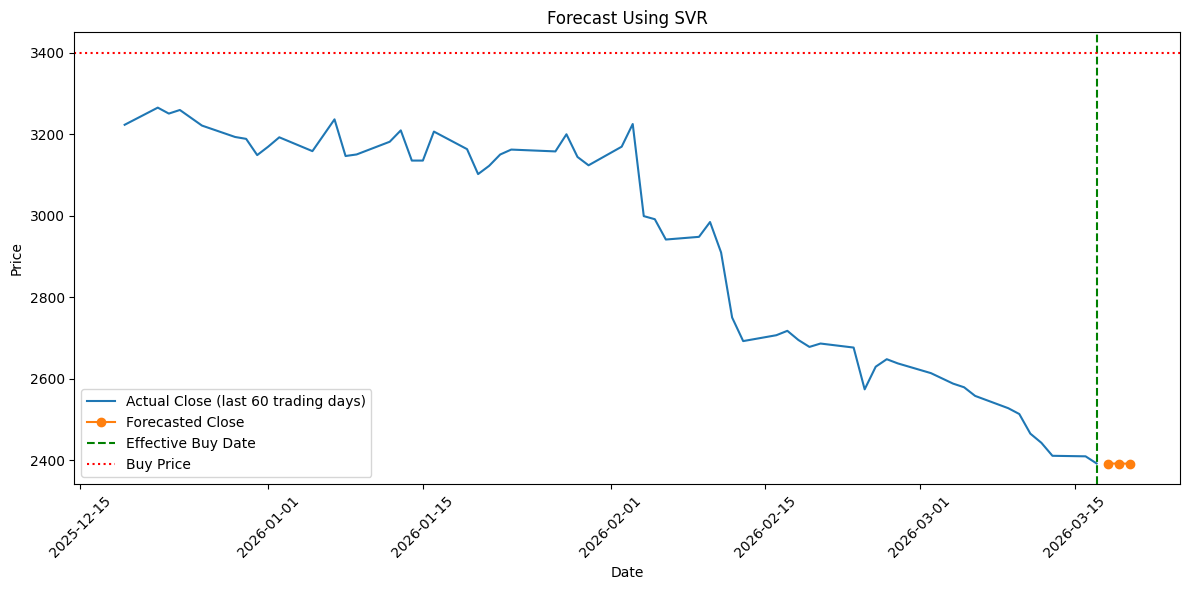


Graph Reading Guide
-------------------
Blue line shows recent actual closing prices before your buy date.
Orange line shows model-predicted future closing prices for each trading day in your selected range.
Green vertical line marks the effective buy date used by the notebook.
Red dotted line shows your entered buy price. If the orange point is above it, that day suggests profit. If below it, that day suggests loss.


In [39]:
# Forecast profit/loss and recommendation using the best model
import matplotlib.pyplot as plt
from pandas.tseries.offsets import BDay

if "best_model" not in globals():
    raise NameError("Run the model comparison cell first so best_model is available.")
if "trained_models" not in globals() or len(trained_models) == 0:
    raise NameError("Run the model training cells first so trained_models is available.")
if "stock_data" not in globals() or stock_data.empty:
    raise NameError("Run the stock selection/data preparation cells first so stock_data is available.")

selected_model_name = best_model["Model"]
selected_model = trained_models.get(selected_model_name)
if selected_model is None:
    raise ValueError(f"The trained model object for {selected_model_name} is not available.")

prediction_feature_columns = globals().get("DEFAULT_FEATURE_COLUMNS", ["Open", "High", "Low", "Close", "Volume", "Log_Return"])
prediction_target_mode = globals().get("TARGET_MODE", "return")

def build_prediction_frame(df, feature_columns, target_mode="return"):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    if "Log_Return" not in df.columns:
        df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))

    missing_features = [col for col in feature_columns if col not in df.columns]
    if missing_features and "create_features" in globals():
        df = create_features(df)
        missing_features = [col for col in feature_columns if col not in df.columns]
    if missing_features:
        raise KeyError(f"Missing feature columns: {missing_features}")

    df["Target_Close_Next_Day"] = df["Close"].shift(-1)
    df["Target_Return_Next_Day"] = (df["Target_Close_Next_Day"] / df["Close"]) - 1.0
    required_columns = feature_columns + ["Date", "Close", "Target_Close_Next_Day", "Target_Return_Next_Day"]
    df = df.dropna(subset=required_columns).reset_index(drop=True)
    return df

def resolve_trading_row(frame, requested_date, label):
    exact_rows = frame[frame["Date"] == requested_date].copy()
    if not exact_rows.empty:
        return exact_rows.iloc[0]
    previous_rows = frame[frame["Date"] <= requested_date].copy()
    if previous_rows.empty:
        nearest_dates = frame.iloc[(frame["Date"] - requested_date).abs().argsort()[:3]]["Date"].dt.strftime("%Y-%m-%d").tolist()
        raise ValueError(f"No trading row found for {label}. Try one of these dates: {nearest_dates}")
    fallback_row = previous_rows.iloc[-1]
    print(f"No exact trading row found for {label}. Using previous available trading date {fallback_row['Date'].strftime('%Y-%m-%d')} instead.")
    return fallback_row

def predict_target_from_history(raw_history_df):
    enriched_history = build_prediction_frame(raw_history_df, prediction_feature_columns, prediction_target_mode)

    if "LSTM" in selected_model_name:
        if "feature_scaler" not in globals() or "target_scaler" not in globals() or "best_config" not in globals():
            raise NameError("Run the LSTM training cell first so feature_scaler, target_scaler, and best_config are available.")
        time_step = int(best_config["time_step"])
        if len(enriched_history) < time_step:
            raise ValueError(f"LSTM needs at least {time_step} prepared rows before forecasting.")
        lstm_window = enriched_history.iloc[-time_step:][prediction_feature_columns].astype(float)
        lstm_window_scaled = feature_scaler.transform(lstm_window)
        X_trade_seq = np.array([lstm_window_scaled], dtype=np.float32)
        predicted_scaled = float(np.asarray(selected_model.predict(X_trade_seq, verbose=0)).reshape(-1)[0])
        return float(target_scaler.inverse_transform(np.array([[predicted_scaled]])).reshape(-1)[0])

    X_trade = enriched_history.iloc[[-1]][prediction_feature_columns].astype(float)
    return float(np.asarray(selected_model.predict(X_trade)).reshape(-1)[0])

def append_future_row(raw_history_df, next_date, predicted_close):
    last_row = raw_history_df.iloc[-1]
    previous_close = float(last_row["Close"])
    next_row = {col: np.nan for col in raw_history_df.columns}
    next_row["Date"] = pd.Timestamp(next_date)
    next_row["Open"] = previous_close
    next_row["High"] = max(previous_close, predicted_close)
    next_row["Low"] = min(previous_close, predicted_close)
    next_row["Close"] = float(predicted_close)
    if "Volume" in raw_history_df.columns:
        next_row["Volume"] = float(last_row["Volume"])
    if "Symbol" in raw_history_df.columns:
        next_row["Symbol"] = last_row.get("Symbol", "")
    return pd.concat([raw_history_df, pd.DataFrame([next_row])], ignore_index=True)

base_raw_df = stock_data.copy()
base_raw_df["Date"] = pd.to_datetime(base_raw_df["Date"])
base_raw_df = base_raw_df.sort_values("Date").reset_index(drop=True)
prediction_df = build_prediction_frame(base_raw_df, prediction_feature_columns, prediction_target_mode)

print("Example input: buy date = 17-03-2026, sell/check date = 15-04-2026, buy price = 3520, quantity = 10")
buy_date_input = input("Enter buy date (YYYY-MM-DD or DD-MM-YYYY): ").strip()
sell_date_input = input("Enter sell/check date within 31 days (YYYY-MM-DD or DD-MM-YYYY): ").strip()
buy_price = float(input("Enter your buy price: ").strip())
quantity_input = input("Enter quantity (press Enter for 1): ").strip()
quantity = int(quantity_input) if quantity_input else 1

buy_date_requested = pd.to_datetime(buy_date_input, dayfirst=True)
sell_date_requested = pd.to_datetime(sell_date_input, dayfirst=True)

trade_row = resolve_trading_row(prediction_df, buy_date_requested, buy_date_input)
effective_buy_date = pd.Timestamp(trade_row["Date"])

if sell_date_requested <= effective_buy_date:
    raise ValueError("Sell/check date must be after the effective buy date.")
if (sell_date_requested - effective_buy_date).days > 31:
    raise ValueError("Please keep the sell/check date within 31 calendar days of the buy date.")

forecast_dates = pd.bdate_range(start=effective_buy_date + BDay(1), end=sell_date_requested)
if len(forecast_dates) == 0:
    forecast_dates = pd.DatetimeIndex([effective_buy_date + BDay(1)])

history_until_buy = base_raw_df[base_raw_df["Date"] <= effective_buy_date].copy().reset_index(drop=True)
forecast_points = []

for future_date in forecast_dates:
    predicted_target = predict_target_from_history(history_until_buy)
    current_close = float(history_until_buy.iloc[-1]["Close"])
    predicted_close = float(target_to_close([current_close], [predicted_target], prediction_target_mode)[0])
    history_until_buy = append_future_row(history_until_buy, future_date, predicted_close)
    forecast_points.append({"Date": pd.Timestamp(future_date), "Predicted_Close": predicted_close})

forecast_df = pd.DataFrame(forecast_points)
forecast_df["Buy_Price"] = buy_price
forecast_df["Per_Share_PL"] = forecast_df["Predicted_Close"] - buy_price
forecast_df["Total_PL"] = forecast_df["Per_Share_PL"] * quantity
forecast_df["Return_Pct"] = (forecast_df["Per_Share_PL"] / buy_price) * 100.0
forecast_df["Action"] = np.where(
    forecast_df["Return_Pct"] >= 2.0,
    "Buy",
    np.where(forecast_df["Return_Pct"] <= -2.0, "Sell", "Hold")
)
predicted_sell_close = float(forecast_df.iloc[-1]["Predicted_Close"])
predicted_profit_per_share = predicted_sell_close - buy_price
predicted_total_profit = predicted_profit_per_share * quantity
predicted_return_pct = (predicted_profit_per_share / buy_price) * 100.0

if predicted_return_pct >= 2.0:
    recommendation = "Buy"
    reason = "The model expects a meaningful upside over the selected period."
elif predicted_return_pct <= -2.0:
    recommendation = "Sell"
    reason = "The model expects downside from the entered buy price over the selected period."
else:
    recommendation = "Hold"
    reason = "The expected move is small, so the model does not see a strong edge either way."

print("Forecast Summary")
print("----------------")
print(f"Best model used     : {selected_model_name}")
print(f"Effective buy date  : {effective_buy_date.strftime('%Y-%m-%d')}")
print(f"Requested sell date : {sell_date_requested.strftime('%Y-%m-%d')}")
print(f"Buy price           : {buy_price:.2f}")
print(f"Quantity            : {quantity}")
print(f"Forecasted sell px  : {predicted_sell_close:.2f}")
print(f"Expected return %   : {predicted_return_pct:.2f}%")
print(f"Per share P/L       : {predicted_profit_per_share:.2f}")
print(f"Total P/L           : {predicted_total_profit:.2f}")
print(f"Recommendation      : {recommendation}")
print(f"Reason              : {reason}")

daily_view = forecast_df.copy()
daily_view["Date"] = daily_view["Date"].dt.strftime("%Y-%m-%d")
daily_view["Predicted_Close"] = daily_view["Predicted_Close"].round(2)
daily_view["Buy_Price"] = daily_view["Buy_Price"].round(2)
daily_view["Per_Share_PL"] = daily_view["Per_Share_PL"].round(2)
daily_view["Total_PL"] = daily_view["Total_PL"].round(2)
daily_view["Return_Pct"] = daily_view["Return_Pct"].round(2)

print()
print("Day-Wise Forecast")
print("-----------------")
display(daily_view[["Date", "Predicted_Close", "Buy_Price", "Per_Share_PL", "Total_PL", "Return_Pct", "Action"]])

print()
print("Simple Explanation")
print("------------------")
for _, row in daily_view.iterrows():
    movement = "profit" if row["Per_Share_PL"] >= 0 else "loss"
    print(
        f"On {row['Date']}, predicted close is {row['Predicted_Close']:.2f}. "
        f"Compared with buy price {row['Buy_Price']:.2f}, this means {movement} of {abs(row['Per_Share_PL']):.2f} per share "
        f"and {abs(row['Total_PL']):.2f} total for quantity {quantity}. Suggested action: {row['Action']}."
    )

actual_candidate_rows = prediction_df[(prediction_df["Date"] > effective_buy_date) & (prediction_df["Date"] <= sell_date_requested)].copy()
if not actual_candidate_rows.empty:
    actual_sell_row = actual_candidate_rows.iloc[-1]
    actual_sell_close = float(actual_sell_row["Close"])
    actual_total_profit = (actual_sell_close - buy_price) * quantity
    print()
    print("Historical Reference")
    print("--------------------")
    print(f"Last actual date in range : {pd.Timestamp(actual_sell_row['Date']).strftime('%Y-%m-%d')}")
    print(f"Actual close             : {actual_sell_close:.2f}")
    print(f"Actual total P/L         : {actual_total_profit:.2f}")

plot_history = prediction_df[prediction_df["Date"] <= effective_buy_date].tail(60)
plt.figure(figsize=(12, 6))
plt.plot(plot_history["Date"], plot_history["Close"], label="Actual Close (last 60 trading days)", color="tab:blue")
plt.plot(forecast_df["Date"], forecast_df["Predicted_Close"], label="Forecasted Close", color="tab:orange", marker="o")
plt.axvline(effective_buy_date, color="green", linestyle="--", label="Effective Buy Date")
plt.axhline(buy_price, color="red", linestyle=":", label="Buy Price")
plt.title(f"Forecast Using {selected_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print()
print("Graph Reading Guide")
print("-------------------")
print("Blue line shows recent actual closing prices before your buy date.")
print("Orange line shows model-predicted future closing prices for each trading day in your selected range.")
print("Green vertical line marks the effective buy date used by the notebook.")
print("Red dotted line shows your entered buy price. If the orange point is above it, that day suggests profit. If below it, that day suggests loss.")


### **Forecasted Profit/Loss Trend**

This plot visualizes the forecasted total profit or loss over the specified prediction period. It clearly shows how the potential profit/loss evolves day-by-day based on the best model's predictions and the user's entered buy price and quantity, helping in quick decision-making.

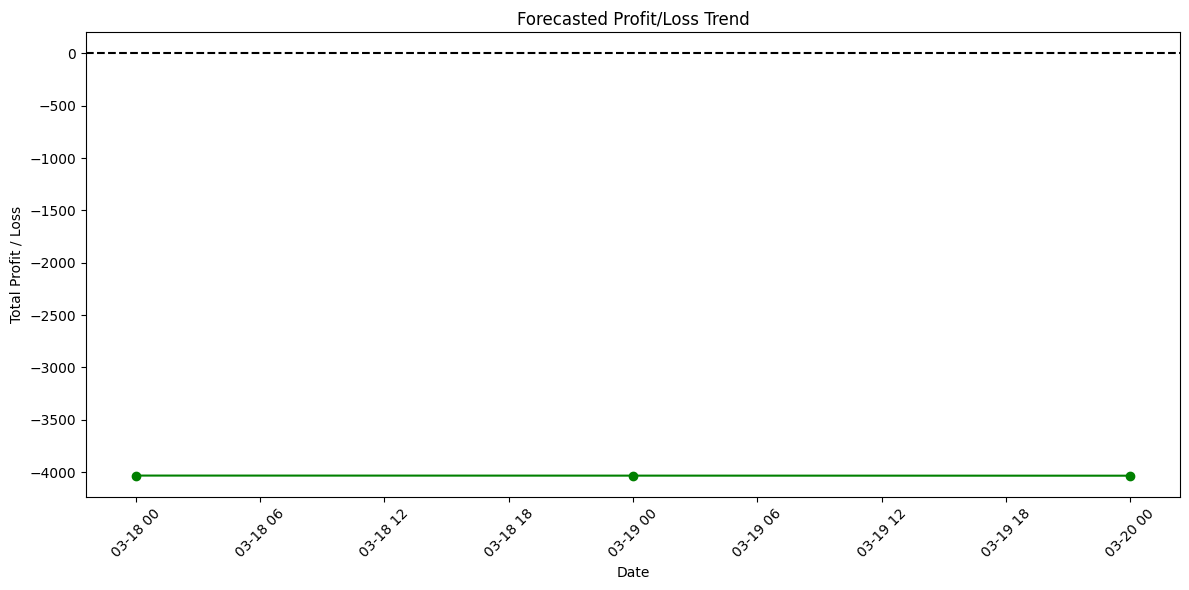

In [40]:
import matplotlib.pyplot as plt

if "forecast_df" not in globals() or forecast_df.empty:
    raise NameError("Run the forecasting cell first so forecast_df is available.")

plot_df = forecast_df.copy()
plot_df["Date"] = pd.to_datetime(plot_df["Date"])

plt.figure(figsize=(12, 6))
plt.plot(plot_df["Date"], plot_df["Total_PL"], marker="o", color="green")
plt.axhline(0, color="black", linestyle="--")
plt.title("Forecasted Profit/Loss Trend")
plt.xlabel("Date")
plt.ylabel("Total Profit / Loss")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Prediction Error (Residual) Analysis**

This section focuses on visualizing the prediction error, also known as the residual, which is the difference between the actual closing price and the model's predicted closing price. A clear understanding of these errors helps in assessing the model's accuracy and identifying any systemic biases or inconsistencies in its predictions.

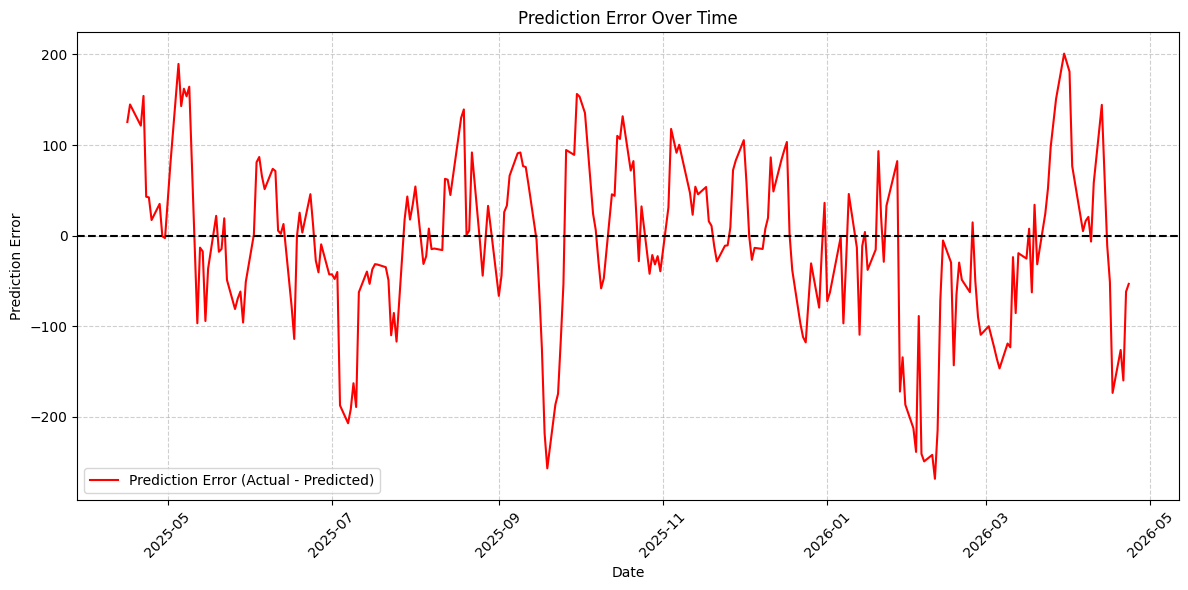


Summary Statistics of Prediction Error:
count    253.000000
mean     -10.499761
std       91.341678
min     -268.254659
25%      -53.229925
50%      -10.677608
75%       47.312159
max      200.911936
Name: Residual, dtype: float64


In [41]:
# Calculating the prediction error (residual)
prediction_error = result_plot_df["Residual"]

plt.figure(figsize=(12, 6))
plt.plot(result_plot_df["Date"], prediction_error, color="red", label="Prediction Error (Actual - Predicted)")
plt.axhline(0, color="black", linestyle="--")
plt.title("Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Prediction Error")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nSummary Statistics of Prediction Error:")
print(prediction_error.describe())